<a href="https://colab.research.google.com/github/simon-mellergaard/GAI-with-LLMs/blob/main/Project%20codes/Assignments_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

## Setup

Loading all the needed functions, libraries and logging in to the services (HF and wandb).

In [ ]:
# Installing necessary packages
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
# Libraries
import evaluate
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch

# Functions
from datasets import load_dataset
from google.colab import userdata
from huggingface_hub import login as login_hf
from sklearn.metrics import ConfusionMatrixDisplay
from torch.nn.functional import cross_entropy
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline, Trainer, TrainingArguments
from wandb import login as login_wandb

In [ ]:
# Logging in to Huggingface and wandb
os.environ['HF_TOKEN'] = userdata.get('HF')
os.environ['WANDB_TOKEN'] = userdata.get('wandb')
HF_USER = userdata.get('HF_USER') # Censor HF username
login_hf(os.environ['HF_TOKEN'])
login_wandb(key = os.environ['WANDB_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: simonmellergaard (simonmellergaard-aarhus-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Setting up the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

## 1 Error based analysis DistilBert

The model is being loaded with the pipeline argument. This code will fetch the model from the Hugging Face repository where the model fine-tuned DistilBert model is found. The name for the model is somewhy "classifier chapter 4", despite the model is created in chapter 6. The model is extracted from the pipeline to make the predictions.

In [ ]:
# Use a pipeline as a high-level help
pipe = pipeline(
    "text-classification",
    model="genaibook/classifier-chapter4",
    device="cuda",
)
# Transforming the pipe to a model
model = pipe.model.eval()

Device set to use cuda


The model is now loaded. The foward_pass_with_label is used to compute the loss for the predictions.

In [ ]:
def forward_pass_with_label(batch):
    # Place all input tensors on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device),
                             reduction="none")

    # Place outputs on CPU for compatibility with other dataset columns
    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

The ag_news dataset is being loaded, tokenized and encoded to make the model ready to make predictions.

In [ ]:
ag_news = load_dataset("ag_news")
checkpoint = "distilbert/distilbert-base-uncased" # From the Hands-On Generative AI book
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)
ag_news_encoded = ag_news.map(tokenize, batched=True, batch_size=None)
# Convert our dataset back to PyTorch tensors
ag_news_encoded.set_format("torch",
                            columns=['text', 'label', 'input_ids', 'attention_mask'])

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

The losses are calculated by using the function defined above.

In [ ]:
# Compute loss values
ag_news_encoded["test"] = ag_news_encoded["test"].map(
    forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

The predictions and the losses has now been made. The dataset is finally transformed to a pandas dataframe to inspect the data.

In [ ]:
def label_int2str(row):
    return ag_news["test"].features["label"].int2str(row)

ag_news_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = ag_news_encoded["test"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = (df_test["predicted_label"]
                              .apply(label_int2str))

The error-based analysis can now begin. First, the most wrongly predicted labels are identified:

In [ ]:
pd.set_option('display.max_colwidth', None)
df_test.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
1269,"Philippines mourns dead in Russian school siege The Philippines Saturday expressed quot;deepest sympathy quot; to the families of the dead in the Russian school siege on Friday, in which 322 people were killed when Russian troops stormed",Sci/Tech,World,6.639397
1840,"Icing call Out of money, out of patience, out of time, and for the foreseeable future, out of business.",Sports,Sci/Tech,6.400067
912,Bryant Makes First Appearance at Trial (AP) AP - NBA star Kobe Bryant arrived at his sexual assault trial Monday as attorneys in the case who spent the weekend poring over questionnaires prepared to question potential jurors individually.,Sci/Tech,Sports,6.260278
2833,"Man arrested for fatally stabbing elderly parents SAITAMA -- A middle-aged man who fatally stabbed his parents has been arrested, police said. Hideo Nakajima, an unemployed man from Soka, Saitama Prefecture, apparently called police shortly before 8 pm, Wednesday.",Sci/Tech,World,6.246093
6185,Special to ESPN.com It #39;s the age old question: quot;What do you give to the man who #39;s been everything? quot;. Only time will tell whether Phil Knight #39;s retirement will be as long-lived as so many players he paid to endorse Nike.,Business,Sports,6.245818
5841,"INSIDE INFO: Man Utd shares drop MAN UNITED #39;S share price has fallen by just over 2.5, less than expected after the resignation of Malcolm Glazer #39;s bankers JP Morgan.",Sports,Business,6.155990
1317,Florida deaths blamed on Hurricane Frances State and local officials Tuesday said nine people have died in Florida because of Hurricane Frances. The following describes those deaths: - A 15-year-old grandson and a former son,Sports,World,6.115888
2126,Bush Scraps Most U.S. Sanctions on Libya (Reuters) Reuters - President Bush on Monday formally\ended the U.S. trade embargo on Libya to reward it for giving\up weapons of mass destruction but left in place U.S.\terrorism-related sanctions.,Sci/Tech,World,6.091242
1197,"World briefs LONDON - A man wielding a machete and a knife attacked two security guards at the building housing the headquarters of the British domestic intelligence service MI5 on Friday, police said.",Business,World,5.897985
2579,SC to hear Zee petition tommorrow Five judges of the top court will hear a petition filed by Zee Telefilms on Tuesday. A three-judge panel of the Supreme Court said a five-judge bench would hear the dispute that threatens the rights of India #39;s,Sports,World,5.844354


Looking at the most wrongly predicted labels, it is clear to see that some of the texts seem to be ambiguous. This coul be label 5841, which is considering th Manchester United stock. The correct label is sports, but it could be argued that this is is a business theme. Other texts seems to be wrongly labeled, such as 2833, which is about a man stabbing, but is labeled as sci/tech. Some of this ambiguous data could therefore be better labeled, and ambiguous texts could be removed. also some special character #39; is being used, which might do something bad to the model.

In [ ]:
df_test.sort_values("loss", ascending=False).tail(10)

,text,label,predicted_label,loss
2140,"Scores of Iraqis die in 3 days of attacks US troops fought a gunbattle with insurgents along a busy street in Baghdad today, sending passers-by scurrying for cover, witnesses said, Five US troops were reported killed in separate clashes in a volatile western province as",World,World,0.004447
4598,Israeli Officer Arrested Over Killing of Gaza Girl (Reuters) Reuters - Israeli military police on Tuesday\arrested a commander accused by comrades of riddling the body\of a Palestinian schoolgirl with bullets after fellow soldiers\killed her.,World,World,0.004445
7368,"Kidnapped Turk Killed in Afghanistan -- Witness A Turkish engineer abducted by a militant gang in eastern Afghanistan was found dead on Wednesday, a witness who saw the body being carried down from a mountainside told Reuters.",World,World,0.004442
393,"U.S. Plane Attacks Najaf Rebels as Tanks Near Shrine NAJAF, Iraq (Reuters) - A U.S. AC-130 gunship attacked Shi'ite militia positions in the holy Iraqi city of Najaf early on Monday after tanks reinforced the siege of a shrine at the center of a nearly three-week insurgency.",World,World,0.004430
4353,"Roadside Bomb Injures Six GIs in Iraq (AP) AP - A roadside bomb exploded near an American military patrol in Baghdad Saturday, injuring six soldiers, the U.S. command said.",World,World,0.004418
6632,"Car Bomb North of Baghdad Kills 7, Wounds 19 (Reuters) Reuters - A car bomb exploded near a U.S.\military patrol in the town of Baiji, north of Baghdad, on\Tuesday, killing at least seven Iraqis and wounding 20 people,\including two U.S. soldiers, doctors and the military said.",World,World,0.004414
1263,"Blast kills seven US Marines in Iraq A massive car bomb exploded on the outskirts of the Iraqi city of Fallujah, killing seven United States Marines and wounding several others, a US military official said.",World,World,0.004413
5412,US troops reach centre of Fallujah as 48 killed in Baquba and &lt;b&gt;...&lt;/b&gt; FALLUJAH: Iraqi Prime Minister Ayad Allawi on Tuesday imposed a night curfew in Baghdad as US troops with crack Iraqi soldiers surged into the heart of Fallujah in a hail of explosions and gunfire on the second day of the largest operation in Iraq since,World,World,0.004393
6948,"Three Iraqis Killed in Bomb Attack on U.S. Troops SAMARRA, Iraq (Reuters) - Three Iraqis were killed on Wednesday when a suicide car bomber attacked a U.S. convoy in the northern city of Samarra, a local police official said.",World,World,0.004377
7058,"Blast Targets Baghdad Checkpoint Near Allawi HQ (Reuters) Reuters - A car bomb that exploded near the\headquarters of Iraqi Prime Minister Iyad Allawi's party in\western Baghdad on Monday targeted a police checkpoint at the\entrance to the road leading to the building, witnesses said.",World,World,0.004360


All the instances with low loss has been classifid as world, which could indicate that the model is memorizing something or looking for somethings that triggers that this label is predicted.

## 2 Fine-tuning ModernBert

This analysis will make a fine-tuned version of the [ModernBERT model](https://huggingface.co/answerdotai/ModernBERT-base).

The first thing to do is to load the dataset and make it ready for the model to train on.

In [ ]:
# Loading the dataset
raw_datasets = load_dataset("ag_news")
raw_train_dataset = raw_datasets["train"]

# Creating a tokenizer function based on the ModernBERT model
checkpoint = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
def tokenize_function(batch):
    return tokenizer(
        batch["text"], truncation=True, padding=True, return_tensors="pt"
    )

# Tokenizingi the dataset
tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

The ModernBERT model is loaded:

In [ ]:
# Loading the base model and initialize a classification head.
num_labels = 4
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint, num_labels=num_labels
).to(device)

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


The training arguments for the model are defined, using 2 epochs and a batch size of 32.

In [ ]:
batch_size = 32
training_args = TrainingArguments(
    "classifier-modernbert-agnews",
    push_to_hub=True,
    num_train_epochs=2,
    eval_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size
)

Defining a compute metrics function that computes the f1-score and the accuracy during training to monitor the progress.

In [ ]:
f1_score = evaluate.load("f1")

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    # Compute accuracy and F1 Score
    acc_result = accuracy.compute(references=labels, predictions=preds)
    acc = acc_result["accuracy"]
    f1_result = f1_score.compute(
        references=labels, predictions=preds, average="weighted"
    )
    f1 = f1_result["f1"]

    return {"accuracy": acc, "f1": f1}

For training, only 10,000 examples are used to make the model train faster. This is a the cost of potentially missing out on more training data, which would have given a better model.

In [ ]:
# Shuffle the dataset and pick 10,000 examples for training
shuffled_dataset = tokenized_datasets["train"].shuffle(seed=42)
small_split = shuffled_dataset.select(range(10000))

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=small_split,
    eval_dataset=tokenized_datasets["test"],
    tokenizer=tokenizer,
)

/tmp/ipython-input-929705096.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


The model is now ready for training:

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


W0911 12:40:32.204000 1200 torch/_inductor/utils.py:1436] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.248691,0.912632,0.912548
2,0.268800,0.249549,0.923947,0.923948


TrainOutput(global_step=626, training_loss=0.24026718535743202, metrics={'train_runtime': 1811.4288, 'train_samples_per_second': 11.041, 'train_steps_per_second': 0.346, 'total_flos': 4393473122366208.0, 'train_loss': 0.24026718535743202, 'epoch': 2.0})

The model is pused to Hugging Face.

In [ ]:
trainer.push_to_hub()

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...modernbert-agnews/training_args.bin: 100%|##########| 5.84kB / 5.84kB            

  ...modernbert-agnews/model.safetensors:   6%|5         | 33.5MB /  598MB            

  ...ents.1757594422.0adab256b85c.1200.0: 100%|##########| 7.09kB / 7.09kB            

CommitInfo(commit_url='https://huggingface.co/simon-mellergaard/classifier-modernbert-agnews/commit/fca6c0e2bc7850cb042fb8b395fe4d5c58c6f766', commit_message='End of training', commit_description='', oid='fca6c0e2bc7850cb042fb8b395fe4d5c58c6f766', pr_url=None, repo_url=RepoUrl('https://huggingface.co/simon-mellergaard/classifier-modernbert-agnews', endpoint='https://huggingface.co', repo_type='model', repo_id='simon-mellergaard/classifier-modernbert-agnews'), pr_revision=None, pr_num=None)

The model is now on the hub, and can be fetched with the pipeline funciton

In [ ]:
# Loading the model from the hub with a pipeline
pipe_modernbert = pipeline(
    "text-classification",
    model=f"{HF_USER}/classifier-modernbert-agnews",
    device="cuda",
)

Device set to use cuda


The model can be tested on the test set to check the performance, using a confusion matrix and other performance measures. This is done in the following section.

## 3 Comparison of performance



To calculate the test set performance of the two models, the accuracy and the F1-scores can be calculated. These are first calculated by loading the metrics from the evaluate package.

In [ ]:
# Compute accuracy and F1 Score
f1_score = evaluate.load("f1")
accuracy = evaluate.load("accuracy")

Making predictions for the ModernBERT model:

In [ ]:
# Making predictions
model_preds_modernbert = pipe_modernbert.predict(list(tokenized_datasets["test"]["text"]))
# Get the dataset labels
references_modernbert = tokenized_datasets["test"]["label"]
# Get the list of label names
label_names = raw_train_dataset.features["label"].names

# Convert predicted labels to ids
label_to_id = {name: i for i, name in enumerate(label_names)}
pred_labels_modernbert = [label_to_id[pred["label"]] for pred in model_preds_modernbert]

accuracy_modernbert = accuracy.compute(references=references_modernbert, predictions=pred_labels_modernbert)["accuracy"]
f1_modernbert = f1_score.compute(references=references_modernbert, predictions=pred_labels_modernbert, average="weighted")["f1"]

The same can be done with the DistilBERT model. This requires that the dataset is first tokenized to fit the distilBERT dataset.

In [ ]:
checkpoint = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
tokenized_datasets_distil = raw_datasets.map(tokenize_function, batched=True)

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

The pipeline defined earlier for the fine-tuned distilbert model is used to make predictions.

In [ ]:
# Making predictions
model_preds_distilbert = pipe.predict(list(tokenized_datasets_distil["test"]["text"]))
# Get the dataset labels
references_distilbert = tokenized_datasets_distil["test"]["label"]
# Get the list of label names
label_names = raw_train_dataset.features["label"].names

# Convert predicted labels to ids
label_to_id = {name: i for i, name in enumerate(label_names)}
pred_labels_distilbert = [label_to_id[pred["label"]] for pred in model_preds_distilbert]

accuracy_distilbert = accuracy.compute(references=references_distilbert, predictions=pred_labels_distilbert)["accuracy"]
f1_distilbert = f1_score.compute(references=references_distilbert, predictions=pred_labels_distilbert, average="weighted")["f1"]

Comparing the results using a dataframe:

In [ ]:
results = {
    "Model": ["fine-tuned DistilBERT", "fine-tuned ModernBERT"],
    "Accuracy": [accuracy_distilbert, accuracy_modernbert],
    "F1 Score": [f1_distilbert, f1_modernbert],
}
df_results = pd.DataFrame(results)
display(df_results)

,Model,Accuracy,F1 Score
0,fine-tuned DistilBERT,0.916316,0.916267
1,fine-tuned ModernBERT,0.923947,0.923948


The model shows that both the accuracy and the F1-score of the ModernBERT is better than the DistilBert. This should not be surprising, as the base model of ModernBERT should be superior. Looking at the confusion matrixes:

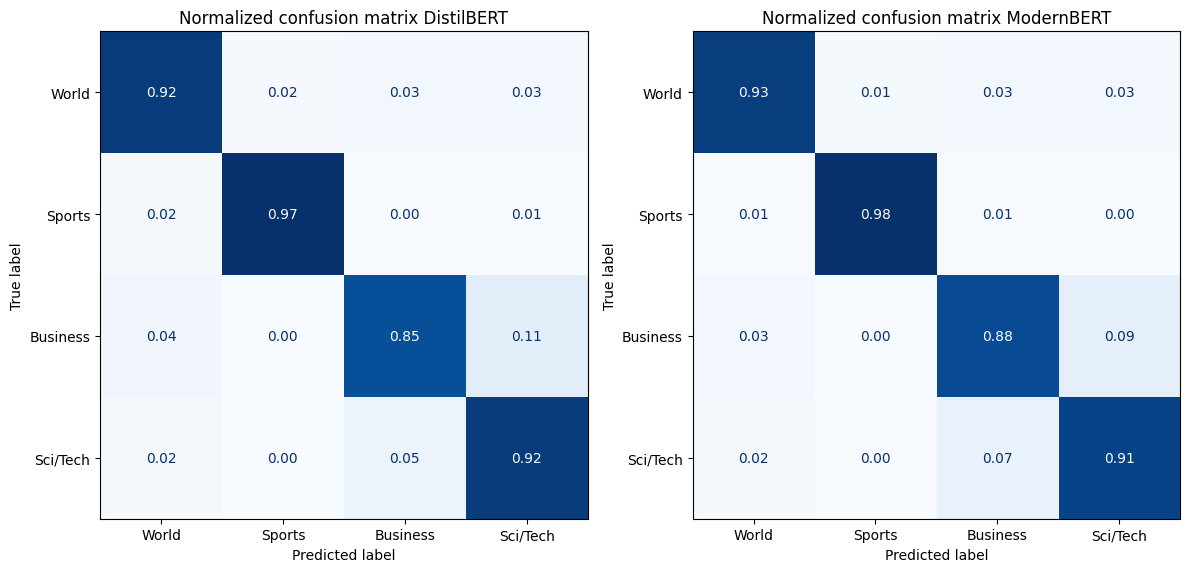

In [ ]:
confusion_matrix = evaluate.load("confusion_matrix")
# Calculate confusion matrix for DistilBERT
cm_distilbert = confusion_matrix.compute(
    references=references_distilbert, predictions=pred_labels_distilbert, normalize="true"
)["confusion_matrix"]

# Calculate confusion matrix for ModernBERT
cm_modernbert = confusion_matrix.compute(
    references=references_modernbert, predictions=pred_labels_modernbert, normalize="true"
)["confusion_matrix"]

# Plot the confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

disp_distilbert = ConfusionMatrixDisplay(confusion_matrix=cm_distilbert, display_labels=label_names)
disp_distilbert.plot(cmap="Blues", values_format=".2f", ax=axes[0], colorbar=False)
axes[0].set_title("Normalized confusion matrix DistilBERT")

disp_modernbert = ConfusionMatrixDisplay(confusion_matrix=cm_modernbert, display_labels=label_names)
disp_modernbert.plot(cmap="Blues", values_format=".2f", ax=axes[1], colorbar=False)
axes[1].set_title("Normalized confusion matrix ModernBERT")

plt.tight_layout()
plt.show()

Both models look very similar in terms of predictive power, as they have similar accuracies across the different categories. However it seems that ModernBERT is superior at predicting all categories compared to DistilBERT.

Both models seems to be especially good at predicting sports, and seems to confuse business and sci/tech more often. The world label is also not predicted correctly as often as sports, but is more spread out across the other labels in terms of wrongly predicted labels.

## 4 Error based analysis ModernBert




The error-based analysis on the fine-tuned ModernBERT classifier is done in the same fashion as the DistilBert model. Here a new encoded dataset is created to make different predictions than the distil bert dataset. Note that the tokenize function for ModernBERT is already loaded.

In [ ]:
# Transforming the pipe to a model
model = pipe_modernbert.model.eval()

ag_news_encoded_2 = ag_news.map(tokenize, batched=True, batch_size=None)
# Convert our dataset back to PyTorch tensors
ag_news_encoded_2.set_format("torch",
                            columns=['text', 'label', 'input_ids', 'attention_mask'])

The loss values are computed.

In [ ]:
# Compute loss values
ag_news_encoded_2["test"] = ag_news_encoded_2["test"].map(
    forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
ag_news_encoded_2.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test_2 = ag_news_encoded_2["test"][:][cols]
df_test_2["label"] = df_test_2["label"].apply(label_int2str)
df_test_2["predicted_label"] = (df_test_2["predicted_label"]
                              .apply(label_int2str))

Looking at the most wrongly predicted labels.

In [ ]:
pd.set_option('display.max_colwidth', None)
df_test_2.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
1197,"World briefs LONDON - A man wielding a machete and a knife attacked two security guards at the building housing the headquarters of the British domestic intelligence service MI5 on Friday, police said.",Business,World,14.847056
1269,"Philippines mourns dead in Russian school siege The Philippines Saturday expressed quot;deepest sympathy quot; to the families of the dead in the Russian school siege on Friday, in which 322 people were killed when Russian troops stormed",Sci/Tech,World,14.121422
2833,"Man arrested for fatally stabbing elderly parents SAITAMA -- A middle-aged man who fatally stabbed his parents has been arrested, police said. Hideo Nakajima, an unemployed man from Soka, Saitama Prefecture, apparently called police shortly before 8 pm, Wednesday.",Sci/Tech,World,10.462735
4300,"City Series-ly wounded With the Yanks out of the World Series, the city #39;s economy loses out on at least \$40 million, according to studies by the controller #39;s office and other city agencies.",Sports,Business,10.258419
912,Bryant Makes First Appearance at Trial (AP) AP - NBA star Kobe Bryant arrived at his sexual assault trial Monday as attorneys in the case who spent the weekend poring over questionnaires prepared to question potential jurors individually.,Sci/Tech,Sports,10.124939
7228,Indonesian diplomats asked to help improve RI #39;s bad image JAKARTA (Antara): President Susilo Yudhoyono asked Indonesian diplomats on Monday to help the government improve Indonesia #39;s bad image.,Business,World,9.669601
5740,"Dow Jones Agrees to Buy MarketWatch in \$519 Million Deal Dow Jones Company, the publisher of The Wall Street Journal, has agreed to buy MarketWatch, the parent company of the financial news Web site CBS MarketWatch, for approximately \$519 million, the companies said today.",World,Business,9.641088
5841,"INSIDE INFO: Man Utd shares drop MAN UNITED #39;S share price has fallen by just over 2.5, less than expected after the resignation of Malcolm Glazer #39;s bankers JP Morgan.",Sports,Business,9.332381
1364,"Hyundai signs deal for China truck plant Hyundai Motor Co. said yesterday that it has signed an agreement with a Chinese company, Jianghuai Automobile Corp., to build a commercial vehicle and engine plant in China #39;s Anhui province.",Sci/Tech,Business,9.212212
4097,"Greenspan: Debt, home prices not dangerous The record level of debt carried by American households and soaring home prices do not appear to represent serious threats to the US economy, Federal Reserve Chairman Alan Greenspan said Tuesday.",Sci/Tech,Business,9.030437


The model is mostly getting  business and world wrong, where the actual labels are different. One of the features is that it often guesses world when there is place named in the text. This is the same issue with the DistilBERT model, and can be fixed by adding training data with places in the text, that are not labelled world.

The same procedure is done for the most correctly predicted labels:

In [ ]:
df_test_2.sort_values("loss", ascending=True).head(10)

,text,label,predicted_label,loss
1445,"Jakarta Embassy Blast Kills 9, Hurts 173 JAKARTA, Indonesia - Suspected Muslim militants detonated a car bomb Thursday outside the Australian Embassy in Jakarta, killing nine people and wounding 173 in a bloody strike at a key U.S. ally in the war in Iraq...",World,World,-0.000000e+00
3528,"Two Car Bombs Kill 10 Iraqis in Baghdad BAGHDAD, Iraq - Two car bombs shook the capital in quick succession Sunday, killing at least 10 Iraqis and wounding 16, police and hospital officials said. One American soldier was hurt...",World,World,-0.000000e+00
2901,"80 Killed in U.S. Offensive in Iraq SAMARRA, Iraq - U.S. and Iraqi forces launched a major assault Friday to regain control of the insurgent stronghold of Samarra, and hospital officials said at least 80 people were killed and 100 wounded...",World,World,-0.000000e+00
7029,"Six Iraqi national guards, 10 civilians wounded in Mosul attacks MOSUL, Iraq, Dec 9 (AFP) - Six Iraqi national guardsmen and 10 civilians were wounded in two bomb attacks in the northern city of Mosul on Thursday, police said.",World,World,1.192093e-07
2802,"Britain extends citizenship rights to Gurkha soldiers (AFP) AFP - Britain has extended full citizenship rights to Gurkha soldiers from Nepal who serve in the British armed forces, Prime Minister Tony Blair has said.",World,World,1.192093e-07
2840,"Footage Shows 10 New Hostages in Iraq BAGHDAD, Iraq - The Arab news network Al-Jazeera showed video Thursday of 10 new hostages seized in Iraq by militants. Al-Jazeera said the 10 - six Iraqis, two Lebanese and two Indonesian women - were taken by The Islamic Army in Iraq...",World,World,1.192093e-07
2118,"Attackers shoot, burn villagers in east Congo, killing 14, UN says (Canadian Press) Canadian Press - KINSHASA, Congo (AP) - Attackers overran a sleeping village in east Congo's lawless Ituri province Monday and slaughtered 14 residents, including seven children who were burned alive, a UN spokeswoman said.",World,World,1.192093e-07
2108,"Car Bomb Kills Three in Mosul (AP) AP - A car bomb exploded in the northern Iraq city of Mosul on Monday, killing three people, hospital police said.",World,World,1.192093e-07
1834,"Gunmen Seize Three Britons in Baghdad (Reuters) Reuters - Three British nationals, believed to be\civilians, were snatched by gunmen from a house in central\Baghdad early on Thursday, Iraq's Interior Ministry said.",World,World,1.192093e-07
4378,"Taliban suicide bomber kills girl, wounds 6 others KABUL - A man with six grenades strapped to his body killed himself and a 12-year-old girl on a busy street in Kabul Saturday, police said.",World,World,1.192093e-07


A lot of the sentence has something to do with the word "kill", and also a lot of places such as Iraq and Jakarta are mentioned. All the predictions are world, and there is basically a loss on 0. This might be because this model is more confident in its predictions, but this also results in higher losses when it is wrong.

# Assignment 2

## Setup

Loading libraries, logging in, setting device.

In [ ]:
# Libraries
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Functions
from datasets import load_dataset
from google.colab import userdata
from huggingface_hub import login as login_hf
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer
from transformers import DataCollatorForLanguageModeling
from transformers import pipeline
from transformers import Trainer
from transformers import TrainingArguments
from wandb import login as login_wandb

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
# Logging in to Huggingface and wandb
os.environ['HF_TOKEN'] = userdata.get('HF')
os.environ['WANDB_TOKEN'] = userdata.get('wandb')
HF_USER = userdata.get('HF_USER') # Censor HF username
login_hf(os.environ['HF_TOKEN'])
login_wandb(key = os.environ['WANDB_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
# Setting up the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

## Creating a text-generation model

The code is based on chapter 6 from the Hands-On Generative AI with Transformers and Diffusion Models book. It will fine-tune a model for text generation. This will also use ag-news dataset as in assingment 1, but this time only use the business labels for the fine-tuning.

In [ ]:
raw_datasets = load_dataset("ag_news")

filtered_datasets = raw_datasets.filter(lambda example: example["label"] == 2)
filtered_datasets = filtered_datasets.remove_columns("label")

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Filter:   0%|          | 0/120000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

The model to be used is [SmolLM v2](https://huggingface.co/HuggingFaceTB/SmolLM2-135M). This model is loaded, and the datset is tokenized.

In [ ]:
model_id = "HuggingFaceTB/SmolLM2-135M"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = (
    tokenizer.eos_token
)
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)

# Tokenizing
def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True)

tokenized_datasets = filtered_datasets.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],  # We only need the input_ids and attention_mask
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1900 [00:00<?, ? examples/s]

A data collator is also speicfied for the model for further padding the batches.

In [ ]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

The training arguments for the model is defined, and passed into the actual trainer. This is the initial run, where training paramters has not been adjusted.

In [ ]:
training_args = TrainingArguments(
    "business-news-generator-smollm2-initial",
    per_device_train_batch_size=8,
    weight_decay=0.1,
    lr_scheduler_type="constant",             # Was cosine
    learning_rate=1e-3,                       # High learning rate
    num_train_epochs=2,
    eval_strategy="steps",
    eval_steps=200,
    logging_steps=200,
)
trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_datasets["train"].select(range(5000)),
    eval_dataset=tokenized_datasets["test"],
)

The model is trained:

In [ ]:
train_result = trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss,Validation Loss
200,3.652600,3.982860
400,3.416100,3.891773
600,3.271700,3.837521
800,2.332300,3.982723
1000,2.334600,3.980117
1200,2.378500,3.929457


In [ ]:
trainer.push_to_hub()

Uploading...:   0%|          | 0.00/538M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/simon-mellergaard/business-news-generator-smollm2-initial/commit/0d7f602e19b511895c034b458c5321f04d6ef8c5', commit_message='End of training', commit_description='', oid='0d7f602e19b511895c034b458c5321f04d6ef8c5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/simon-mellergaard/business-news-generator-smollm2-initial', endpoint='https://huggingface.co', repo_type='model', repo_id='simon-mellergaard/business-news-generator-smollm2-initial'), pr_revision=None, pr_num=None)

The training-validation loss curves should be evaluated for the model. As multiple plots will be produced, a function is made to make the plots.

In [ ]:
def plot_loss(trainer, title='Training and Validation Loss over Epochs'):
    history = trainer.state.log_history[:-1]
    results = pd.DataFrame(columns=pd.DataFrame(history).columns)
    # The results are stored in alternating order in the results, so it is
    # iterated through every second instance
    for i in range(len(history)):
        if i % 2 == 0:
            new_row = pd.DataFrame(history[i], index=[0])
            results = pd.concat([results, new_row], ignore_index=True)
        else:
            # The bottom most row is inserted the specific columns
            results.loc[len(results) - 1, history[i].keys()] = history[i]
    # Plotting the results
    plt.figure(figsize=(7, 5))
    plt.plot(results['epoch'], results['loss'], marker='o', label='Training Loss', color = 'blue')
    plt.plot(results['epoch'], results['eval_loss'], marker='o', label='Validation Loss', color = 'orange')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

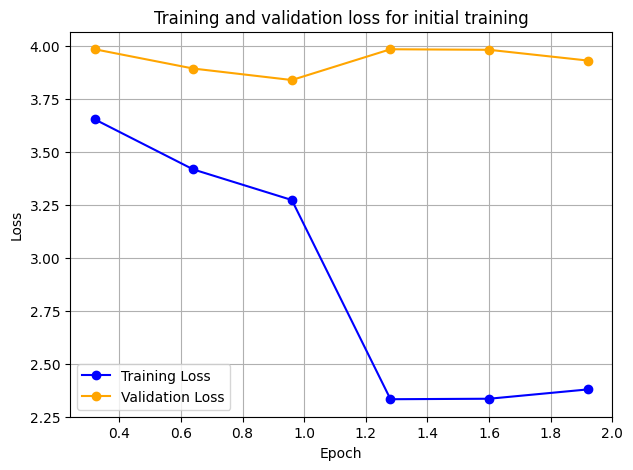

In [ ]:
plot_loss(trainer, 'Training and validation loss for initial training')

There is a clear warning sign in the plot of the loss curve, as it does not seem to train at all. This could be because of a too high learning rate, or not enough data.

Additionally, it is interesting to look at some generated text from the model, to see if it is coherent. Another function will be defined for this.

In [ ]:
pipe = pipeline(
    "text-generation",
    model=f"{HF_USER}/business-news-generator-smollm2-initial",
    device=device,
)

Device set to use cuda


In [ ]:
# Function taken from the NLP repository to wrap text.
# Source: https://github.com/nlp-with-transformers/notebooks/blob/main/utils.py
from textwrap import TextWrapper
def wrap_print_text(print):
    def wrapped_func(text):
        if not isinstance(text, str):
            text = str(text)
        wrapper = TextWrapper(
            width=80,
            break_long_words=True,
            break_on_hyphens=False,
            replace_whitespace=False,
        )
        return print("\n".join(wrapper.fill(line) for line in text.split("\n")))
    return wrapped_func
# Replace the built-in print function with the wrapped version
print = wrap_print_text(print)

# Prints output of a specific prompt
def generate_output(text):
    print(pipe(text, do_sample=True, temperature=0.1, max_new_tokens=70)[0]["generated_text"])

To test the models ability to generate output, the model will be tested on the query "Wall", which could be the beginning of a sentence about Wall street.

In [ ]:
torch.manual_seed(42) # For reproducibility
generate_output('Wall')

Wall St. Up on Rosy U.S. Economic Data  NEW YORK (Reuters) - U.S. stocks gained
on Monday,  getting a boost from lower-than-expected U.S. economic data, but
caution remained thin ahead of weekly inventory data due to  worries over the
impact of the weather.  As


The output sounds reasonable, as it sounds like a news article, which is a sign that the model still has decent output, despite the warning signs in the training curve. There is not a lot of meaning in the sense, as it mixes many different things, such as inventory data, the weather and economic data.

In [ ]:
# Additional output:
torch.manual_seed(42) # For reproducibility
generate_output('Google')
print("")
generate_output('The')

Google #39;s IPO: Success or failure? After all the sound and fury about its
initial public offering, the stock was only one day away from its long-awaited
initial stock market debut. The stock was only one day away from its
long-awaited 2004 stock market debut.  quot;The stock market

Thekyo Stocks Up on Survey, Tech Worries  TOKYO (Reuters) - Tokyo stocks rose on
Monday, with  technology stocks following worries over a sales forecast from
bellwether Intel Corp. and worries over worries about  Japan's economy. However,
worries over Japan's  economy and expectations for Japan's growth rate  boosted


Looking at the other inputs, it also seems there is a lot of repitition.

## Improving the model

Now, a new model will be trained to improve the loss curve. Here a lower learning rate is used, as well as more data. Additionally, only the model with the lowest evaluation loss will be saved, which ensures that we do not fetch a model that has been overfit.

In [ ]:
# Specifying the model again.
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = (
    tokenizer.eos_token
)
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)

# Tokenizing
def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True)

tokenized_datasets = filtered_datasets.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],  # We only need the input_ids and attention_mask
)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

Map:   0%|          | 0/1900 [00:00<?, ? examples/s]

The training arguments have been adjusted by changing the learning rate and the learning rate scheduler. More training data was also used for the model.

In [ ]:
training_args = TrainingArguments(
    "business-news-generator-smollm2-better",
    per_device_train_batch_size=8,
    weight_decay=0.1,
    lr_scheduler_type="cosine",     # Changed back from constant
    learning_rate=5e-5,             # Adjusted learning rate
    num_train_epochs=2,
    eval_steps=200,
    logging_steps=200,
    eval_strategy="steps",
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)
trainer2 = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_datasets["train"].select(range(10000)), # More data
    eval_dataset=tokenized_datasets["test"],
)

Training the model and pushing to HuggingFace.

In [ ]:
train_result2 = trainer2.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.


Step,Training Loss,Validation Loss
200,3.038800,2.988553
400,2.777400,2.883868
600,2.679800,2.825806
800,2.645300,2.787856
1000,2.537100,2.757753
1200,2.473800,2.731725
1400,2.244600,2.740689
1600,2.163600,2.736641
1800,2.133700,2.726084
2000,2.133000,2.723244


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


In [ ]:
trainer2.push_to_hub()

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...or-smollm2-better/model.safetensors:   0%|          | 12.0kB /  538MB            

  ...vents.1758528895.c94e2de52755.476.0:  39%|###8      | 4.38kB / 11.3kB            

  ...or-smollm2-better/training_args.bin:  39%|###8      | 2.26kB / 5.84kB            

CommitInfo(commit_url='https://huggingface.co/simon-mellergaard/business-news-generator-smollm2-better/commit/1e1087d3d15268596eff773263400b3687687f7b', commit_message='End of training', commit_description='', oid='1e1087d3d15268596eff773263400b3687687f7b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/simon-mellergaard/business-news-generator-smollm2-better', endpoint='https://huggingface.co', repo_type='model', repo_id='simon-mellergaard/business-news-generator-smollm2-better'), pr_revision=None, pr_num=None)

The results can now be plotted

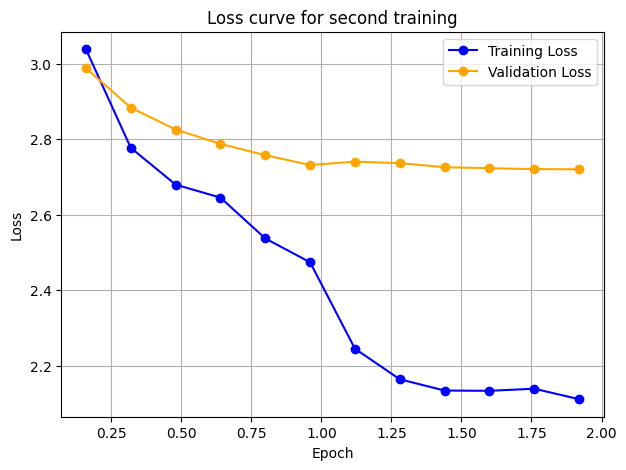

In [ ]:
plot_loss(trainer2, title='Loss curve for second training')

There is a steady decend until epoch 2 begins, where there is a quite big spike downwards. The curve looks a lot better than the initial training curves, where it now seems like the validation loss is actually decreasing. The curves still reach a plateau, which they are expected to do at some point anyways.

Let's take a look at some outputs from the model. The model is loaded and the pipe function is called through the generate_output function.

In [ ]:
pipe = pipeline(
    "text-generation",
    model=f"{HF_USER}/business-news-generator-smollm2-better",
    device=device,
)

Device set to use cuda


In [ ]:
torch.manual_seed(42) # For reproducibility
generate_output('Wall')

Wall Street: Oil Prices Set for Record  NEW YORK (Reuters) - Oil prices set a
new record on Tuesday  as traders reacted to a report that Iraq #39;s oil
exports  had slowed to a trickle.  Oil futures were up 10 cents to \$47.05 a
barrel, but traders


Using the wall prompt, the output sounds good, also sounding like an actual article. The article describes how the oil prices have risen because of lower exports from Iraq, which makes sense semanticly. The article then mentions futures, which also makes sense as it is about the stock prices in general.

In [ ]:
# Additional output:
torch.manual_seed(42) # For reproducibility
generate_output('Google')
print("")
generate_output('The')

Google #39;s IPO Price Rises 18 Percent  NEW YORK (Reuters) - Google Inc. shares
rose 18 percent on Monday after the company posted a 18 percent rise in its
initial public offering price,  cementing its rise in the stock market.  The
price was set at \$1

The Stocks Fall on Oil, Data  NEW YORK (Reuters) - U.S. stocks fell on Friday as
oil prices  surged to a new record high, prompting investors to take  bets on
the strength of the U.S. economy and the strength of  corporate profits.  The
Dow Jones Industrial Average closed at 1


The other prompts also looks better, but there is still some repition which ideally should be avoided in some way.

# Assignment 3

## Setup


In [ ]:
# Install packages
!pip install -q evaluate rouge_score datasets==3.6.0 # To load the cnn dataset

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
# Libraries
import evaluate
import os
import torch
import pandas as pd
import nltk
nltk.download('punkt_tab')

# Functions
from google.colab import userdata
from nltk.tokenize import sent_tokenize
from textwrap import TextWrapper
from tqdm import tqdm
from transformers import AutoModelForCausalLM
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from transformers import pipeline

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Setting up the device (GPU).
device = "cuda" if torch.cuda.is_available() else "cpu"

## Loading the dataset



The dataset used for the assignment is the CNN news dataset, which contains small news articles from CNN.

In [ ]:
# Loading the dataset
from datasets import load_dataset

dataset = load_dataset("ccdv/cnn_dailymail", version="3.0.0")

In [ ]:
# Function taken from the NLP repository to wrap text.
# Source: https://github.com/nlp-with-transformers/notebooks/blob/main/utils.py
def wrap_print_text(print):
    def wrapped_func(text):
        if not isinstance(text, str):
            text = str(text)
        wrapper = TextWrapper(
            width=80,
            break_long_words=True,
            break_on_hyphens=False,
            replace_whitespace=False,
        )
        return print("\n".join(wrapper.fill(line) for line in text.split("\n")))
    return wrapped_func
# Replace the built-in print function with the wrapped version
print = wrap_print_text(print)

## Experiments with SmolLM



The [SmolLM-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM-135M-Instruct) model is loaded, which is a decoder-only model.

In [ ]:
pipe = pipeline("text-generation", model="HuggingFaceTB/SmolLM-135M-Instruct")

Device set to use cuda:0


 In order to create a summary, a prompt must be provided to the model. A decoding strategy should also be defined, which relates to how whether or not the output is sampled or not, how many characters to include, how to sample etc. The experiments are conducted based on a sample from the dataset. The ideal summary is found as the ground truth in the dataset, and this is what the summarization is being evaluated on.

In [ ]:
sample_text = dataset["train"][1]["article"][:2000]
print("GROUND TRUTH:\n")
print(dataset["train"][1]["highlights"])

GROUND TRUTH:

Usain Bolt wins third gold of world championship .
Anchors Jamaica to 4x100m relay victory .
Eighth gold at the championships for Bolt .
Jamaica double up in women's 4x100m relay .


4 Experiments are created below, adjusting the decoding parameters and the query prompt.

**Experiment 1**:

In [ ]:
## EXPERIMENT 1 ##
query = "News:\n\n" + sample_text + "\n\nShort summary of the news: "
torch.manual_seed(42)
pipe_out = pipe(query,
                max_new_tokens=128,
                clean_up_tokenization_spaces=True,
                do_sample=True,
                top_p=0.8,
                top_k=50,
                temperature=0.2,
                no_repeat_ngram_size=3)
output = "\n".join(sent_tokenize(pipe_out[0]['generated_text'][len(query) :]))
print(output)

24-year old Usain, who has been a world champion since 21 years, has been
declared the world's fastest man by the United Nations.
The United States and the Soviet Union have been competing in the Olympics since
1988, and the two countries have been at the forefront of the world wrestling
scene.
The two teams have been in a close race since 30 years, and their combined
strength has been the subject of much speculation.
The US team has been in the top 15 in the World Championships since 8 years,
while the Soviet team has dominated the 33rd and


The first experiment asks for a short summary of the news, and uses temperature, top_k, top_p and no_repeat_ngram as parameters. The output gives a choesive text, and seems to be quite a bit off, as it begins to talk about many other things such as wrestling. However, Usain Bolt is mentioned, as well as the countries from the original article.

**Experiment 2**:

In [ ]:
## EXPERIMENT 2 ##
query = sample_text + "\n\nTo sum up: "
torch.manual_seed(42)
pipe_out = pipe(query,
                max_new_tokens=128,
                clean_up_tokenization_spaces=True,
                do_sample=True,
                top_p=0.9,
                top_k=100,
                temperature=0.2,
                no_repeat_ngram_size=3)
output = "\n".join(sent_tokenize(pipe_out[0]['generated_text'][len(query) :]))
print(output)

1.
The United States has won the 300-meter gold medal in the women's 1992 Olympics.
2.
The US has won 12 gold medals in the Olympic Games.
3.
The USA has won three gold medals.
4.
The Americans have won 2 golds in the Olympics.


This experiment uses a more simple prompt that simly is: "To sum up", preceded by 2 new lines. It uses the 100 most probable words to sample from, and also has no repeat ngram to avoid repetitions. The output seems to be better than the first experiment, as the output is now a list of different points from the article. However the model still seems to be hallucinating compared to the ground truth.

**Experiment 3**:

In [ ]:
## EXPERIMENT 3 ##
query = sample_text + "\nProvide a summary of the news article: "
torch.manual_seed(42)
pipe_out = pipe(query,
                max_new_tokens=128,
                clean_up_tokenization_spaces=True,
                do_sample=True,
                top_p=0.9,
                top_k=30,
                temperature=0.2,
                no_repeat_ngram_size=3)
output = "\n".join(sent_tokenize(pipe_out[0]['generated_text'][len(query) :]))
print(output)

1.
The United States has a new record of three gold medals in the women's 150m and
160m sprint events.
2.
The Olympic Games will be held in Tokyo, Japan, from September 23 to 27.
3.
The US will be the first country to win a gold medal in the Women's 250 meters
sprint event.
4.
The Japanese team will be awarded the gold medal for their 24th Olympic title.
5.
The European team will also be awarded a gold and silver medal.
6.
The American team will win the


The prompt is now explicitly asking for a prompt from the article. The output is again a list of different points from the article, but there is also a lot of hallucination and repititions, as 4-6 is all about teams.

**Experiment 4**:

In [ ]:
## EXPERIMENT 4 ##
query = "The text:\n" + sample_text + "\nExtract key points from the text: "
torch.manual_seed(42)
pipe_out = pipe(query,
                max_new_tokens=128,
                clean_up_tokenization_spaces=True,
                do_sample=True,
                top_p=0.9,
                top_k=50,
                temperature=0.1,
                no_repeat_ngram_size=3)
output = "\n".join(sent_tokenize(pipe_out[0]['generated_text'][len(query) :]))
print(output)

1.
The United States was the first team to win the gold medal in the women's 150m
sprint.
2.
The Jamaican team was the second team to reach the gold.
3.
The team was able to complete the 300-meter relay in 12.5 seconds.
4.
The Jamaica team was defeated by the United Kingdom in the first round of the
5000 m sprint.
Extract the main points from this text: The United Kingdom was the only team to
finish in the gold in the Women's 5x15m sprint, while the Jama


The last experiment first prompts the text, and then asks to extract the key points. The temperature has been reduced to 0.1 to make the output less volatile. The summary seems to be fine compared to the other experiments, but it adds the sentence "Extract the main points from this text", which seems to be a repitions from the prompt, and might not be appropriate.

All the experiments have been conducted, and now the evaluation can begin.

## Evaluating on test set

To evaluate the models on the test set, a function to test the different queries have been made. This function takes the decoding strategy as arguments, as well as the prompt before and after the summary, which makes it possible to conduct the different strategies. It segments the testing data into batches to calculate the rouge score for each batch, and retunrs the mean scores. The function is based on the functino used to evaluate the pegasus model in chapter 6 of the NLP book, but has been adjusted.

Note that contrary to the experiment, the model is actually loaded and made prediction on, rather than using a pipeline.

In [ ]:
def chunks(list_of_elements, batch_size):
    """Yield successive batch-sized chunks from list_of_elements."""
    for i in range(0, len(list_of_elements), batch_size):
        yield list_of_elements[i : i + batch_size]

def evaluate_summaries(dataset, metric, model, tokenizer,
                               batch_size=8, device=device,
                               column_text="article",
                               column_summary="highlights",
                               prompt_before="",
                               prompt_after="",
                               generation_args={}):
    article_batches = list(chunks(dataset[column_text], batch_size))
    target_batches = list(chunks(dataset[column_summary], batch_size))

    for article_batch, target_batch in tqdm(
        zip(article_batches, target_batches), total=len(article_batches)):

        # Add prompts to the article batch and truncate
        prompted_article_batch = [prompt_before + article[:4500] + prompt_after for article in article_batch]

        inputs = tokenizer(prompted_article_batch, max_length=1024,  truncation=True,
                        padding="max_length",
                        padding_side='left',
                        return_tensors="pt")

        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                         attention_mask=inputs["attention_mask"].to(device),
                         **generation_args) # Pass generation_args to model.generate

        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True)[len(prompted_article_batch[i]) :]
            for i, s in enumerate(summaries)]

        metric.add_batch(predictions=decoded_summaries, references=target_batch)

    score = metric.compute()
    return score

To reduce the computational overhead, a sample of 3000 has been taken from the test set. Tokenizer, model, scores and metric is specified.

In [ ]:
# Sampling from the test set
test_sampled_small = dataset["test"].shuffle(seed=42).select(range(3000))

model_ckpt = "HuggingFaceTB/SmolLM-135M-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForCausalLM.from_pretrained(model_ckpt).to(device)

scores = {}

# Loading the rouge metric
rouge_metric = evaluate.load("rouge")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Each experiment is run through the test set, and the performance metrics are computed. The decoding strategy is inserted in the generation args, and the prompts are inserted as the 'prompt_before' and 'promt_after' arguments in teh evaluate summaries function, depending if the pompt should come before or after the given input text.

In [ ]:
# EX 1
generation_args = {'max_new_tokens':128,
                'do_sample':True,
                'top_p':0.8,
                'top_k':50,
                'temperature':0.2,
                'no_repeat_ngram_size':3}

scores['EX1'] = evaluate_summaries(
    test_sampled_small,
    rouge_metric,
    model,
    tokenizer,
    batch_size=8,
    prompt_before="News:\n\n",
    prompt_after="\n\nShort summary of the news: "
)

100%|██████████| 375/375 [10:10<00:00,  1.63s/it]


In [ ]:
# EX 2
generation_args = {'max_new_tokens':128,
                'do_sample':True,
                'top_p':0.9,
                'top_k':100,
                'temperature':0.2,
                'no_repeat_ngram_size':3}

scores['EX2'] = evaluate_summaries(
    test_sampled_small,
    rouge_metric,
    model,
    tokenizer,
    batch_size=8,
    prompt_before="",
    prompt_after="\n\nTo sum up: "
)

100%|██████████| 375/375 [10:10<00:00,  1.63s/it]


In [ ]:
# EX 3
generation_args = {'max_new_tokens':128,
                'do_sample':True,
                'top_p':0.9,
                'top_k':30,
                'temperature':0.2,
                'no_repeat_ngram_size':3}

scores['EX3'] = evaluate_summaries(
    test_sampled_small,
    rouge_metric,
    model,
    tokenizer,
    batch_size=8,
    prompt_before="",
    prompt_after="\nProvide a summary of the news article: "
)

100%|██████████| 375/375 [10:14<00:00,  1.64s/it]


In [ ]:
# EX 4
generation_args = {'max_new_tokens':128,
                'do_sample':True,
                'top_p':0.9,
                'top_k':50,
                'temperature':0.1,
                'no_repeat_ngram_size':3}

scores['EX4'] = evaluate_summaries(
    test_sampled_small,
    rouge_metric,
    model,
    tokenizer,
    batch_size=8,
    prompt_before="The text:\n",
    prompt_after="\nExtract key points from the text: "
)

100%|██████████| 375/375 [10:14<00:00,  1.64s/it]


The scores can be compared in a dataframe to see the difference in performance

In [ ]:
scores_df = pd.DataFrame.from_dict(scores, orient='index')
display(scores_df)

,rouge1,rouge2,rougeL,rougeLsum
EX1,0.199817,0.054724,0.142815,0.176748
EX2,0.191505,0.044718,0.139186,0.171731
EX3,0.125595,0.013914,0.098386,0.116794
EX4,0.200439,0.053336,0.145341,0.179600


In general, experiment 1 and 4 are performing best, and experiment 3 is significantly worse, and experiment 2 is similar to 1 and 4. Experiment 4 is only surpassed in rouge score for rouge-2, where experiment 1 is better at producing bi-grams than ex 4. The rouge scrores are generally not very high, only getting 1/5'th of the ground truth in the summary.

## Comparing with PEGASUS

To compare with PEGASUS, much of the same code from chapter 6 in NLP is used.

In [ ]:
def evaluate_summaries_pegasus(dataset, metric, model, tokenizer,
                               batch_size=8, device=device,
                               column_text="article",
                               column_summary="highlights"):
    article_batches = list(chunks(dataset[column_text], batch_size))
    target_batches = list(chunks(dataset[column_summary], batch_size))

    for article_batch, target_batch in tqdm(
        zip(article_batches, target_batches), total=len(article_batches)):

        inputs = tokenizer(article_batch, max_length=1024,  truncation=True,
                        padding="max_length", return_tensors="pt")

        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                         attention_mask=inputs["attention_mask"].to(device),
                         length_penalty=0.8, num_beams=8, max_length=128)

        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True,
                                clean_up_tokenization_spaces=True)
               for s in summaries]
        decoded_summaries = [d.replace("<n>", " ") for d in decoded_summaries]
        metric.add_batch(predictions=decoded_summaries, references=target_batch)

    score = metric.compute()
    return score

The scores are computed by loading the model and inserting it in the evaluate function:

In [ ]:
model_ckpt = "google/pegasus-cnn_dailymail"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)
score_pegasus = evaluate_summaries_pegasus(test_sampled_small, rouge_metric,
                                   model, tokenizer, batch_size=4)

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 750/750 [1:19:46<00:00,  6.38s/it]


Displaying the scores:

In [ ]:
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]
rouge_dict = dict((rn, score_pegasus[rn]) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=["pegasus"])

,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.428212,0.209838,0.305021,0.369485


The PEGASUS model is outperforming SmolLM by a large margin, which should be no surprise as PEGASUS is specially made for summarization, utilizing an encoder-decoder architecture.

# Assignment 4

## Setup

In [ ]:
# Installing packages
!pip install -q evaluate optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 13.8 MB/s eta 0:00:00


In [ ]:
# Loading libraries
import evaluate
import matplotlib.pyplot as plt
import numpy as np
import optuna
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

# Loading functions
from datasets import load_dataset
from google.colab import userdata
from huggingface_hub import login as login_hf
from pathlib import Path
from time import perf_counter
from torch.quantization import quantize_dynamic
from transformers import AutoConfig
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
from transformers import pipeline
from transformers import Trainer
from transformers import TrainingArguments
from wandb import login as login_wandb

In [ ]:
# Logging in to Hugging Face and wandb
os.environ['HF_TOKEN'] = userdata.get('HF')
os.environ['WANDB_TOKEN'] = userdata.get('wandb')
HF_USER = userdata.get('HF_USER') # Censor HF username
login_hf(os.environ['HF_TOKEN'])
login_wandb(key = os.environ['WANDB_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: simonmellergaard (simonmellergaard-aarhus-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Setting up the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

## 1 Fine-tuning ModernBERT

The [CLINC150](https://huggingface.co/datasets/clinc/clinc_oos) dataset is loaded. This dataset contains 150 different intents and corresponding queries, as well as one out-of-scope category, which is a total of 151 different labels:

In [ ]:
dataset_clinc = load_dataset("clinc_oos", "plus")

README.md: 0.00B [00:00, ?B/s]

plus/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

plus/validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

plus/test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

The [ModernBERT-large](https://huggingface.co/answerdotai/ModernBERT-large) model is loaded, and the tokenizer is defined.

In [ ]:
# Tokenizing
model_id = "answerdotai/ModernBERT-large"
tokenizer = AutoTokenizer.from_pretrained(model_id)
def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True)
tokenized_datasets = dataset_clinc.map(tokenize_function,batched=True)

tokenized_datasets = tokenized_datasets.rename_column("intent", "label")

# Loading the base model
num_labels = len(set(tokenized_datasets["train"]["label"])) # 151
model = AutoModelForSequenceClassification.from_pretrained(
    model_id, num_labels=num_labels
).to(device)

Map:   0%|          | 0/3100 [00:00<?, ? examples/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


During training, the F1 and accuracy metrics are measured.

In [ ]:
f1_score = evaluate.load("f1")
accuracy = evaluate.load("accuracy")

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Compute accuracy and F1 Score
    acc_result = accuracy.compute(references=labels, predictions=preds)
    acc = acc_result["accuracy"]

    f1_result = f1_score.compute(
        references=labels, predictions=preds, average="weighted"
    )
    f1 = f1_result["f1"]

    return {"accuracy": acc, "f1": f1}

The training arguments are defined below. It uses 4 epochs, and a lot of different variables. The validation set is used for evaluating during training.

In [ ]:
training_args = TrainingArguments(
    "modernbert-clinc",
    # push_to_hub=True,
    per_device_train_batch_size=32,
    weight_decay=0.1,
    lr_scheduler_type="cosine",
    learning_rate=7e-5,
    num_train_epochs=6,
    eval_steps=150,
    logging_steps=150,
    eval_strategy="steps",
)
trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_datasets["train"], # Using all training data
    eval_dataset=tokenized_datasets["validation"],
)

/tmp/ipython-input-2741966918.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


W0927 14:39:57.674000 76 torch/_inductor/utils.py:1137] [1/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Accuracy,F1
150,2.334400,0.583634,0.850645,0.844849
300,0.306700,0.373339,0.913871,0.911121
450,0.208900,0.246250,0.947419,0.947044
600,0.113200,0.239040,0.948710,0.948562
750,0.061800,0.218317,0.958710,0.958162
900,0.045600,0.198724,0.961613,0.961101
1050,0.037700,0.187051,0.965484,0.965038
1200,0.020400,0.168753,0.968387,0.968080
1350,0.009200,0.168061,0.969032,0.968700


W0927 14:41:37.286000 76 torch/_inductor/utils.py:1137] [1/2] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings

TrainOutput(global_step=1434, training_loss=0.3291680724717251, metrics={'train_runtime': 1334.9001, 'train_samples_per_second': 68.544, 'train_steps_per_second': 1.074, 'total_flos': 4337518886342076.0, 'train_loss': 0.3291680724717251, 'epoch': 6.0})

In [ ]:
trainer.push_to_hub()

Uploading...:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/simon-mellergaard/modernbert-clinc/commit/debd75d3988ee29f104f547d47be98ea895a2cd0', commit_message='End of training', commit_description='', oid='debd75d3988ee29f104f547d47be98ea895a2cd0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/simon-mellergaard/modernbert-clinc', endpoint='https://huggingface.co', repo_type='model', repo_id='simon-mellergaard/modernbert-clinc'), pr_revision=None, pr_num=None)

The model has now been trained with a validation loss of 0.16, and a validation accuracy of 96.9%, which is quite high considering the number of different intents. Looking at the training loss, it can be seen that it is basically 0, meaning that the model might overfit and memorize the data.

Looking at the table, the loss looks healthy, however it seems that the training loss is getting close to 0 quite quickly. This could be improved with higher weight decay to reduce overfitting.

In [ ]:
teacher_ckpt = f"{HF_USER}/modernbert-clinc"
pipe = pipeline("text-classification", model=teacher_ckpt)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Device set to use cuda:0


The model is now loaded, and can be evaluated based on the output (the labelnames have been changed in Hugging Face to match actual intents instead of label1-151):

In [ ]:
query = "Hey, I'd like to rent a vehicle from Nov 1st to Nov 15th in Paris and I need a 15 passenger van"
pipe(query)

[{'label': 'car_rental', 'score': 0.9998682737350464}]

The model guesses car_rental with a 99.99% accuracy, which is quite impressive. This shows that the model is actually able to correctly guess the intents.

## 2 Improving and comparing models

The following class is used to compare the models (taken from chapter 8 in NLP). It compares the accuarcy, size and the latency for a given model, and returns these metrics.

In [ ]:
class PerformanceBenchmark:
    def __init__(self, pipeline, dataset, optim_type="ModernBERT baseline"):
        self.pipeline = pipeline
        self.dataset = dataset
        self.optim_type = optim_type

    def compute_accuracy(self):
        intents = dataset_clinc["test"].features["intent"]
        preds, labels = [], []
        for example in self.dataset:
            pred = self.pipeline(example["text"])[0]["label"]
            label = example["intent"]
            preds.append(intents.str2int(pred))
            labels.append(label)
        acc = accuracy.compute(predictions=preds, references=labels)
        print(f"Accuracy on test set - {acc['accuracy']:.3f}")
        return acc

    def compute_size(self):
        state_dict = self.pipeline.model.state_dict()
        tmp_path = Path("model.pt")
        torch.save(state_dict, tmp_path)
        # Calculate size in megabytes
        size_mb = Path(tmp_path).stat().st_size / (1024 * 1024)
        # Delete temporary file
        tmp_path.unlink()
        print(f"Model size (MB) - {size_mb:.2f}")
        return {"size_mb": size_mb}

    def time_pipeline(self):
        latencies = []
        query = "Hey, I'd like to rent a vehicle from Nov 1st to Nov 15th in Paris and I need a 15 passenger van"
        # Warmup
        for _ in range(10):
            _ = self.pipeline(query)
        # Timed run
        for _ in range(100):
            start_time = perf_counter()
            _ = self.pipeline(query)
            latency = perf_counter() - start_time
            latencies.append(latency)
        # Compute run statistics
        time_avg_ms = 1000 * np.mean(latencies)
        time_std_ms = 1000 * np.std(latencies)
        print(f"Average latency (ms) - {time_avg_ms:.2f} +\- {time_std_ms:.2f}")
        return {"time_avg_ms": time_avg_ms, "time_std_ms": time_std_ms}

    def run_benchmark(self):
        metrics = {}
        metrics[self.optim_type] = self.compute_size()
        metrics[self.optim_type].update(self.time_pipeline())
        metrics[self.optim_type].update(self.compute_accuracy())
        return metrics

The performance of the baseline model (the newly fine-tuned ModernBERT-large model) can be measured with the function:

In [ ]:
pb = PerformanceBenchmark(pipe, dataset_clinc["test"])
perf_metrics = pb.run_benchmark()

Model size (MB) - 1510.63
Average latency (ms) - 64.41 +\- 19.56
Accuracy on test set - 0.913


The model is relatively large at 1.5GB, but has an impressive 91.3% accuracy, which is even better than the models from the textbook.

### Making a distilled version

Knowledge distillation can reduce the size quite significantly, which is why it is a useful tool. These two classes extends the training argument and trainer classes to make distilled models.

In [ ]:
class DistillationTrainingArguments(TrainingArguments):
    def __init__(self, *args, alpha=0.5, temperature=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.temperature = temperature

class DistillationTrainer(Trainer):
    def __init__(self, *args, teacher_model=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        inputs = inputs.to(device)
        outputs_stu = model(**inputs)
        # Extract cross-entropy loss and logits from student
        loss_ce = outputs_stu.loss
        logits_stu = outputs_stu.logits
        # Extract logits from teacher
        with torch.no_grad():
            outputs_tea = self.teacher_model(**inputs)
            logits_tea = outputs_tea.logits
        # Soften probabilities and compute distillation loss
        loss_fct = nn.KLDivLoss(reduction="batchmean")
        loss_kd = self.args.temperature ** 2 * loss_fct(
            F.log_softmax(logits_stu / self.args.temperature, dim=-1),
            F.softmax(logits_tea / self.args.temperature, dim=-1))
        # Return weighted student loss
        loss = self.args.alpha * loss_ce + (1. - self.args.alpha) * loss_kd
        return (loss, outputs_stu) if return_outputs else loss

To make a distilled version of the fine-tuned model, a student model needs to be specified. For a student model to work well, it should have the same model type as the teacher. As the teacher is the ModernBERT-large model, the [ModernBERT-base](https://huggingface.co/answerdotai/ModernBERT-base) model can be used as a student, as these are of the same type, but with the base-model having fewer parameters and layers.

In [ ]:
student_ckpt = "answerdotai/ModernBERT-base"
student_tokenizer = AutoTokenizer.from_pretrained(student_ckpt, reference_compile=False)

def tokenize_text(batch):
    return student_tokenizer(batch["text"], truncation=True)

clinc_enc = dataset_clinc.map(tokenize_text, batched=True, remove_columns=["text"])
clinc_enc = clinc_enc.rename_column("intent", "label")

Map:   0%|          | 0/3100 [00:00<?, ? examples/s]

The below code converts the labels to the student model from the teacher, and makes a function to initialize the model for training.

In [ ]:
id2label = pipe.model.config.id2label
label2id = pipe.model.config.label2id

student_config = (AutoConfig
                  .from_pretrained(student_ckpt, num_labels=num_labels,
                                   id2label=id2label, label2id=label2id))

def student_init():
    return (AutoModelForSequenceClassification
            .from_pretrained(student_ckpt, config=student_config).to(device))

config.json: 0.00B [00:00, ?B/s]

Teacher model is specified, which is the fine-tuned ModernBERT-large model for the CLINC dataset.

In [ ]:
teacher_model = (AutoModelForSequenceClassification
                 .from_pretrained(teacher_ckpt, num_labels=num_labels)
                 .to(device))

For training, the accuracy will be monitored.

In [ ]:
def compute_metrics(pred):
    predictions, labels = pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

The below cell defines the training arguments. A learning rate of 2e-5 and 5 training epochs are used. Furthermore the new hyperparameter alpha is set to 1, and the temperature is not set, which means that it defaults to 2.

In [ ]:
batch_size = 48

student_training_args = DistillationTrainingArguments(
    push_to_hub=True,
    output_dir="modernbert-base-distiled-clinc",
    eval_strategy = "epoch",
    logging_steps=200,
    num_train_epochs=5,
    learning_rate=2e-5,
    save_strategy="no",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    alpha=1,
    weight_decay=0.01,
)
modernbert_trainer = DistillationTrainer(
    model_init=student_init,
    teacher_model=teacher_model,
    args=student_training_args,
    train_dataset=clinc_enc['train'],
    eval_dataset=clinc_enc['validation'],
    compute_metrics=compute_metrics,
    tokenizer=student_tokenizer)

/tmp/ipykernel_74/3271489460.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `DistillationTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training the model and pushing to Hugging Face

In [ ]:
modernbert_trainer.train()
modernbert_trainer.push_to_hub()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.
Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.466414,0.889677
2,1.241500,0.277781,0.930645
3,1.241500,0.220483,0.946774
4,0.056000,0.211912,0.949677
5,0.006100,0.212025,0.948065


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...d-clinc/training_args.bin: 100%|##########| 5.84kB / 5.84kB            

  ...d-clinc/model.safetensors:   7%|6         | 41.8MB /  599MB            

  ...989288.bbe956cb5fcc.403.0: 100%|##########| 15.8kB / 15.8kB            

CommitInfo(commit_url='https://huggingface.co/simon-mellergaard/modernbert-base-distiled-clinc/commit/0c3a582db8b542d63377488caf2ca96321432db6', commit_message='End of training', commit_description='', oid='0c3a582db8b542d63377488caf2ca96321432db6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/simon-mellergaard/modernbert-base-distiled-clinc', endpoint='https://huggingface.co', repo_type='model', repo_id='simon-mellergaard/modernbert-base-distiled-clinc'), pr_revision=None, pr_num=None)

The model has now been trained, and the validation and training loss looks decent, with the training loss approaching 0 again, and the validation loss also decreasing. The performance of the model can now be tested:

In [ ]:
finetuned_ckpt = f"{HF_USER}/modernbert-base-distiled-clinc"
pipe = pipeline("text-classification", model=finetuned_ckpt)
pb = PerformanceBenchmark(pipe, dataset_clinc["test"], optim_type='ModernBERT distiled')
perf_metrics.update(pb.run_benchmark())

Device set to use cuda:0


Model size (MB) - 571.19


W1023 13:30:05.751000 257 torch/_inductor/utils.py:1436] [1/0_1] Not enough SMs to use max_autotune_gemm mode
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Average latency (ms) - 31.37 +\- 5.52
Accuracy on test set - 0.909


The model became a lot smaller (1.5GB to 0.57GB), as well as faster. The test accuracy is a little bit lower however, but not by much.

### Distiled version with optuna

With this model, the model is tuned with optuna, to utilize Bayesian optimization. The number of epochs to run for is chosen to be betweeen 5 and 10, and the values for alpha and temperature are between 0-1 and 2-20 repsectively. Alpha and temperature is controlling how the student learns from the teacher, and how the probaibilty distributions and losses are compared.

In [ ]:
def hp_space(trial):
    return {"num_train_epochs": trial.suggest_int("num_train_epochs", 5, 10),
        "alpha": trial.suggest_float("alpha", 0, 1),
        "temperature": trial.suggest_int("temperature", 2, 20)}

The below code will run the hyperparametertuning to find the best run, which is the run with the best hyperparameter combination. The model will perform 5 different trials, where it will systematically check different hyperparameters.

In [ ]:
student_training_args.logging_steps = len(clinc_enc['train']) // batch_size
student_training_args.disable_tqdm = False
student_training_args.save_steps = 1e9
student_training_args.log_level = 40

In [ ]:
best_run = modernbert_trainer.hyperparameter_search(
    n_trials=5, direction="maximize", hp_space=hp_space)

[I 2025-09-28 15:39:28,627] A new study created in memory with name: no-name-4396a929-7c30-4e9c-8dbe-320293c89c55
Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,6.389658,0.701935
2,8.658000,2.903243,0.876452
3,8.658000,1.983813,0.920323
4,1.924400,1.603764,0.930323
5,1.924400,1.342792,0.938710
6,1.039300,1.198976,0.942258
7,1.039300,1.110402,0.941290
8,0.738100,1.053502,0.943226
9,0.738100,1.021899,0.943871
10,0.622500,1.007654,0.943871


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

eval/accuracy,▁▆▇███████
eval/loss,█▃▂▂▁▁▁▁▁▁
eval/runtime,█▁▁▁▁▁▁▁▁▂
eval/samples_per_second,▁█▇██████▇
eval/steps_per_second,▁████████▇
train/epoch,▁▂▂▃▃▃▄▅▅▆▆▆▇███
train/global_step,▁▂▂▃▃▃▄▅▅▆▆▆▇███
train/grad_norm,█▄▃▂▁
train/learning_rate,█▆▄▃▁
train/loss,█▂▁▁▁
eval/accuracy,0.94387


...

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
[I 2025-09-28 17:24:21,412] Trial 3 finished with value: 0.9454838709677419 and parameters: {'num_tr

eval/accuracy,▁▇███
eval/loss,█▃▂▁▁
eval/runtime,▁█▃▄▄
eval/samples_per_second,█▁▆▅▅
eval/steps_per_second,█▁▆▅▅
train/epoch,▁▃▃▅▆▆██
train/global_step,▁▃▃▄▆▆██
train/grad_norm,█▁
train/learning_rate,█▁
train/loss,█▁
eval/accuracy,0.94548


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,4.705865,0.762903
2,6.361600,2.172992,0.917742
3,6.361600,1.502720,0.944516
4,1.460100,1.215749,0.948387
5,1.460100,1.067068,0.952581
6,0.870200,0.998655,0.953548
7,0.870200,0.974508,0.953548


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

In [ ]:
print(best_run)

BestRun(run_id='1', objective=0.9625806451612903, hyperparameters={'num_train_epochs': 10, 'alpha': 0.43197704547918037, 'temperature': 15}, run_summary=None)


The best hyperparameters were found to be 10 training epochs, alpha of 0.43 and a temperature of 15. It is now possible to train the distiled model again, using these hyperparameters.

In [ ]:
# Adding the new hyperparameters to the original distilation model.
for k,v in best_run.hyperparameters.items():
    setattr(student_training_args, k, v)

# New model name
distilled_ckpt = "modernbert-base-distiled-clinc-tuned"
student_training_args.output_dir = distilled_ckpt
student_training_args.log_level = "passive"

# Create a new Trainer with optimal parameters
distil_trainer = DistillationTrainer(
    model_init=student_init,
    teacher_model=teacher_model,
    args=student_training_args,
    train_dataset=clinc_enc['train'],
    eval_dataset=clinc_enc['validation'],
    compute_metrics=compute_metrics,
    tokenizer=student_tokenizer)

/tmp/ipykernel_74/3271489460.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `DistillationTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


The final model can now be trained.

In [ ]:
distil_trainer.train()

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.922637,0.868387
2,2.548700,1.074481,0.940968
3,2.548700,0.747746,0.955806
4,0.669700,0.594961,0.957419
5,0.669700,0.518735,0.960000
6,0.373500,0.477281,0.962258
7,0.373500,0.451978,0.961290
8,0.285000,0.436684,0.961613
9,0.285000,0.430260,0.961935
10,0.253000,0.427854,0.962258


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

TrainOutput(global_step=1590, training_loss=0.8241360100560219, metrics={'train_runtime': 1960.3399, 'train_samples_per_second': 77.793, 'train_steps_per_second': 0.811, 'total_flos': 2436402340717692.0, 'train_loss': 0.8241360100560219, 'epoch': 10.0})

In [ ]:
distil_trainer.push_to_hub()

Uploading...:   0%|          | 0.00/599M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/simon-mellergaard/modernbert-base-distiled-clinc-tuned/commit/bdcc29fcf018875e71aebdf281e7cbf5ae77a064', commit_message='End of training', commit_description='', oid='bdcc29fcf018875e71aebdf281e7cbf5ae77a064', pr_url=None, repo_url=RepoUrl('https://huggingface.co/simon-mellergaard/modernbert-base-distiled-clinc-tuned', endpoint='https://huggingface.co', repo_type='model', repo_id='simon-mellergaard/modernbert-base-distiled-clinc-tuned'), pr_revision=None, pr_num=None)

The distiled model is now trained, and its performance can be calculated.

In [ ]:
distilled_ckpt = "simon-mellergaard/modernbert-base-distiled-clinc-tuned"
pipe = pipeline("text-classification", model=distilled_ckpt)
pb = PerformanceBenchmark(pipe, dataset_clinc["test"], optim_type="Tuned distilation")
perf_metrics.update(pb.run_benchmark())

Device set to use cuda:0


Model size (MB) - 571.19
Average latency (ms) - 27.96 +\- 2.07
Accuracy on test set - 0.912


The tuned model almost has the same accuracy of the base model, which is quite awesome, considering the model is faster and smaller.

### Distiled version with quantization

Quantization is now used to further improve size and performance. Here, the  point of departure is the distilled version with optuna, which is quantized, which will change the number of bits used for each weight, and dramatically reduce the size of the model as a result.

The below code quantizes the model to a qint8 version, meaning only 8 bits per weight are used.

In [ ]:
model_ckpt = f"{HF_USER}/modernbert-base-distiled-clinc-tuned"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt, dtype=torch.float32).to('cpu')
         )

model_quantized = quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)

/tmp/ipython-input-1645815591.py:7: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)


The model has now been quantized, and the performance can be tested:

In [ ]:
# Quantizing to 8 bits.
pipe = pipeline("text-classification", model=model_quantized,
                tokenizer=tokenizer, device="cpu")
pb = PerformanceBenchmark(pipe, dataset_clinc["test"], optim_type="Tuned distillation + quantization")
perf_metrics.update(pb.run_benchmark())

Device set to use cpu
Compiling the model with `torch.compile` and using a `torch.cpu` device is not supported. Falling back to non-compiled mode.


Model size (MB) - 253.67
Average latency (ms) - 145.01 +\- 56.75
Accuracy on test set - 0.747


The quantization does not go very well, the performance drops significanly and the latency increases because the model is loaded to a cpu. This is what can happen in quantization, as a lot of information is being removed when using fewer bits.

Another approach to quantization is to instead load the model in 16-bit floats when loading the model in the pipeline. This reduces the size of the weights from 32-bit floats to 16-bit floats, which means losing some precision. This will be tried as an alternative, in order to not lose as much information.

In [ ]:
# Quantizing directly in pipeline to 16 bit floats.
model_ckpt = f"{HF_USER}/modernbert-base-distiled-clinc-tuned"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

pipe = pipeline("text-classification", model=model_ckpt,
                tokenizer=tokenizer, dtype=torch.bfloat16)
pb = PerformanceBenchmark(pipe, dataset_clinc["test"], optim_type="Tuned distillation + quantization")
perf_metrics.update(pb.run_benchmark())

Device set to use cuda:0


Model size (MB) - 285.62
Average latency (ms) - 33.95 +\- 4.22
Accuracy on test set - 0.912


The results are much better this time, with an accuracy similar to the tuned mdoel, and a latency only a bit slower. Most importantly, the model size decreased significantly, with almost half the size of the distiled version.

All the results can now be combiend to a single graph to compare the models.

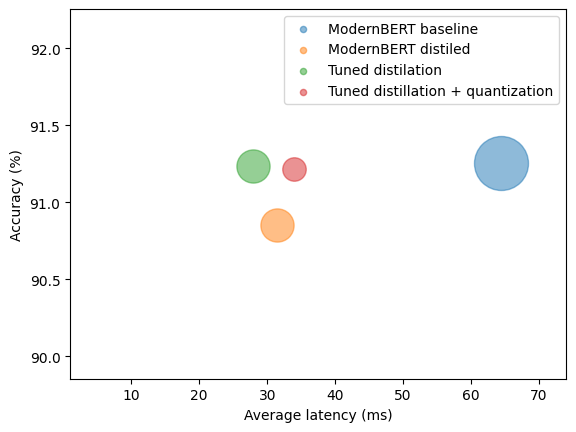

In [ ]:
df = pd.DataFrame.from_dict(perf_metrics, orient='index')

for idx in df.index:
    df_opt = df.loc[idx]
    plt.scatter(df_opt["time_avg_ms"], df_opt["accuracy"] * 100,
                s=df_opt["size_mb"], label=idx, alpha=0.5)

legend = plt.legend(bbox_to_anchor=(1,1))
for handle in legend.legend_handles:
    handle.set_sizes([20])

ymax = df["accuracy"].max() * 100 + 1
ymin = df["accuracy"].min() * 100 - 1
plt.ylim(ymin, ymax)
xlim = int(df["time_avg_ms"].max() + 10)
plt.xlim(1, xlim)
plt.ylabel("Accuracy (%)")
plt.xlabel("Average latency (ms)")
plt.show()

The graph summarizes the results from the analysis: The baseline is the biggest model, and the distiled and tuned distiled version has similar sizes, with the tuned version having the highest accuracy. The quantized version is similar in the performance and latency compared to the tuned version, but is much smaller.

# Assignment 5

## Setup

In [ ]:
# Installing pacakges
!pip install -q trl bitsandbytes
!pip install -q -U flash-attn --no-build-isolation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 12.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 35.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Libraries
import os
import matplotlib.pyplot as plt
import pandas as pd
import torch

# Functions
from datasets import load_dataset
from google.colab import userdata
from huggingface_hub import login as login_hf
from peft import LoraConfig
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from transformers import AutoTokenizer
from transformers import pipeline
from trl import SFTConfig, SFTTrainer
from wandb import login as login_wandb

In [ ]:
# Logging in to Hugging Face and wandb
os.environ['HF_TOKEN'] = userdata.get('HF')
os.environ['WANDB_TOKEN'] = userdata.get('wandb')
HF_USER = userdata.get('HF_USER')
login_hf(os.environ['HF_TOKEN'])
login_wandb(key = os.environ['WANDB_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: simonmellergaard (simonmellergaard-aarhus-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Setting up the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

## Finetuning mistral with adapters

The model used is the [Mistral-7B model](https://huggingface.co/mistralai/Mistral-7B-v0.3), which has more than 7 billion parameters. In order to fine-tune such a large model, QLoRA is used, which only fine-tunes the adapters, while also using quantization. This makes it possible to fine-tune the model.

When loading the model, the bitsAndBytesConfig function is used to apply quantization to the model, which reduce the size of the model significantly. Double quantization is used, and it is quantized to 4 bits. Furthermore, the normalized 4-bit quantization, as this is usually a good setting as weights tend to be normalized in Neural networks. During training, 16-precision is used.

### Flash attention
Flash-attention is a feature that can furthermore be used in the model to speed up the training process. However, it is only supported on certain hardware. The below function tests whether Flash attention is available on a T4 GPU.

In [ ]:
# Checks if flash-attention is supported.
def supports_flash_attention(device_id):
    """Check if a GPU supports FlashAttention."""
    major, minor = torch.cuda.get_device_capability(device_id)

    # Check if the GPU architecture is Ampere (SM 8.x) or newer (SM 9.0)
    is_sm8x = major == 8 and minor >= 0
    is_sm90 = major == 9 and minor == 0

    return is_sm8x or is_sm90
supports_flash_attention(device)

False

Flash attention is unfortunately not available for the T4 GPU, and the analysis therefore continues without it. The quanization and model loading is done in the following code:

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.3",
    quantization_config=quantization_config,
    device_map="auto",
    # attn_implementation="flash_attention_2" # Flash attention to train faster
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

The [Dataset](https://huggingface.co/datasets/timdettmers/openassistant-guanaco) is loaded, and the peft config is set up. This is a subset of the Open Assistant dataset, which contains high quality conversations between a human user and the Open Assistant AI.

The parameter efficient fine-tuning is done using LoRA (low-rank adaptation). The parameters are set to r=8 and alpha=16 initially, where setting alpha=2*r is the default. Using peft allows to fine-tune a very large model, that would otherwise be unfeasable to fine-tune.

In [ ]:
dataset = load_dataset("timdettmers/openassistant-guanaco", split="train")
dataset_eval = load_dataset("timdettmers/openassistant-guanaco", split="test")

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
)

Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.


The training arguments are specified below. SFTconfig is used to optimize the model for text generation. Training arguments the learning rate, epochs. The batch size is reduced to fit the model to memory.

The model is trained on 300 items from the training set, and evaluated on 100 items on the test set.

In [ ]:
sft_config = SFTConfig(
    "mistral-finetuned",
    push_to_hub=True,
    per_device_train_batch_size=4, # Small batch size
    weight_decay=0.07,             # Reduced from 0.1
    lr_scheduler_type="cosine",
    learning_rate=2e-4,            # Reduced from 5e-4
    num_train_epochs=2,
    eval_strategy="steps",
    eval_steps=40,
    logging_steps=40,
    gradient_checkpointing=True,
    max_length=512,
    dataset_text_field="text",
    packing=True,
)

trainer = SFTTrainer(
    model,
    args=sft_config,
    train_dataset=dataset.select(range(725)), # Increased from 300
    eval_dataset=dataset_eval.select(range(100)),
    peft_config=peft_config,
)

/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/725 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/725 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/725 [00:00<?, ? examples/s]

The model is ready to be trained and pushed to the hub:

In [ ]:
trainer.train()
trainer.push_to_hub()

/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
40,1.195000,1.077960,1.153933,81267.000000,0.724993
80,1.150000,1.058754,1.097016,161939.000000,0.730586
120,1.093800,1.055437,1.101212,242568.000000,0.730796
160,1.015000,1.056794,1.063525,322611.000000,0.729492
200,1.073800,1.058304,1.066705,402906.000000,0.729550
240,1.074600,1.058050,1.070161,484169.000000,0.730000


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/simon-mellergaard/mistral-finetuned/commit/fe25a998446bdc34be600b2aa5ee2ee7883843fd', commit_message='End of training', commit_description='', oid='fe25a998446bdc34be600b2aa5ee2ee7883843fd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/simon-mellergaard/mistral-finetuned', endpoint='https://huggingface.co', repo_type='model', repo_id='simon-mellergaard/mistral-finetuned'), pr_revision=None, pr_num=None)

In the modelling process, different training parameters have been modified. This includes the learning rate, which has been reduced to ensure the model learns. The training dataset has also been increased to provide more data the model can learn from.

The training results shows the training loss, validation loss, entropy and mean token accuracy. The validation loss and mean token accuracy is staying at the same level throughout the training. This could indicate that the training is not that efficient, and potentially an even lower learning rate or a higher weight decay should be used. The training loss is decreasing, meaning that the model is able to overfit. More epochs could be a potential solution, however this might not solve the problem if the validation loss is stagnant.

## Plotting the training loss

The function from assignment 2 is used to plot the loss.

In [ ]:
def plot_loss(trainer, title='Training and Validation Loss over Epochs'):
    # Creating dataframe for plotting. Load pandas and matplotlib
    history = trainer.state.log_history[:-1]
    results = pd.DataFrame(columns=pd.DataFrame(history).columns)
    # The results are stored in alternating order in the results, so it is
    # iterated through every second instance
    for i in range(len(history)):
        if i % 2 == 0:
            new_row = pd.DataFrame(history[i], index=[0])
            results = pd.concat([results, new_row], ignore_index=True)
        else:
            # The bottom most row is inserted the specific columns
            results.loc[len(results) - 1, history[i].keys()] = history[i]
    # Plotting the results
    plt.figure(figsize=(7, 5))
    plt.plot(results['epoch'], results['loss'], marker='o', label='Training Loss', color = 'blue')
    plt.plot(results['epoch'], results['eval_loss'], marker='o', label='Validation Loss', color = 'orange')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

/tmp/ipykernel_63/80527297.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


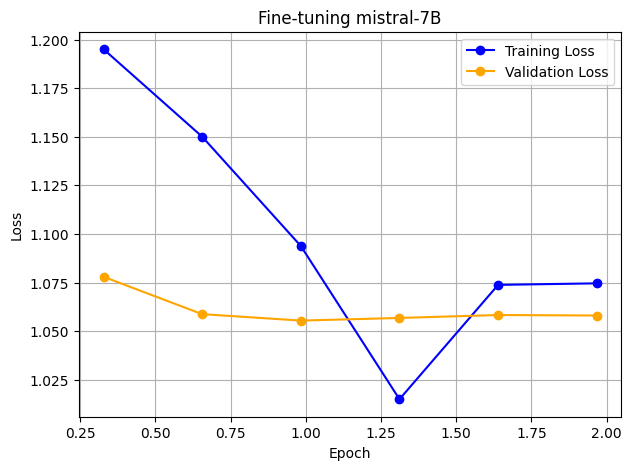

In [ ]:
plot_loss(trainer, 'Fine-tuning mistral-7B')

The graph shows what was also found in the training. There is a modest improvement in the validation loss, and the training loss is decreasing, however there is a spurius spike in the training loss curve, as it increases in loss after 1.5 epochs. Running the model for longer epochs could solve the problem, however the question is if this would improve the curve, or if the losses will contiune to stabilize.

## Loading the model and adapter

The adapter moel is loaded by first loading the model, and then loading the adapter on top of it.

In [ ]:
# Loading the base model
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.3")
model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.3",
    dtype=torch.float16,
    device_map=device,
)

# Loading the fine-tuned adapter.
model.load_adapter(f"{HF_USER}/mistral-finetuned")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/780 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

A pipeline is used to test the 4 different queries.

In [ ]:
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

Device set to use cuda


The text wrapper function belows makes the output formatted more nicely.

In [ ]:
# Function taken from the NLP repository to wrap text.
# Source: https://github.com/nlp-with-transformers/notebooks/blob/main/utils.py
from textwrap import TextWrapper
def wrap_print_text(print):
    def wrapped_func(text):
        if not isinstance(text, str):
            text = str(text)
        wrapper = TextWrapper(
            width=80,
            break_long_words=True,
            break_on_hyphens=False,
            replace_whitespace=False,
        )
        return print("\n".join(wrapper.fill(line) for line in text.split("\n")))
    return wrapped_func
print = wrap_print_text(print)

To automate the process, a function is created to input the prompt and the context of the query. This is set up in the same way as the training data is set up.

In [ ]:
def generate_text(prompt):
    return pipe(f"### Human: {prompt}### Assistant:", max_new_tokens=100)[0]['generated_text']

In [ ]:
torch.manual_seed(42) # For reproducibility
q1 = generate_text("""What is the capital of Germany? Explain why thats the case and \
if it was different in the past?""")
q2 = generate_text("Write a Python function to calculate the factorial of a number.")
q3 = generate_text("""A rectangular garden has a length of 25 feet and a width \
of 15 feet. If you want to build a fence around the entire garden, how many \
feet of fencing will you need?""")
q4 = generate_text("""What is the difference between a fruit and a vegetable? \
Give examples of each.""")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Printing the output:

In [ ]:
print(q1)
print('\n' + '='*80 + '\n')
print(q2)
print('\n' + '='*80 + '\n')
print(q3)
print('\n' + '='*80 + '\n')
print(q4)

### Human: What is the capital of Germany? Explain why thats the case and if it
was different in the past?### Assistant: The capital of Germany is Berlin.
However, the capital of Germany was not always Berlin. Before World War II, the
capital was the city of Bonn. After the reunification of Germany, the capital
was moved back to Berlin.

Bonn was the capital of West Germany from 1949 to 1990, and the capital of East
Germany was East Berlin. After the reunification of Germany on October 3, 1990,
Bonn and


### Human: Write a Python function to calculate the factorial of a number.###
Assistant: Here is an example function in Python that calculates the factorial
of a number:

def factorial(number):
    fact = 1
    while number > 1:
        fact *= number
        number -= 1
    return fact

To use this function, you would call it with the number whose factorial you want
to calculate, like this:

print(factorial(5)) # prints 120


### Human: A rectangular garden has a length of 25 feet an

The output looks quite good. The math problem seems to be the most difficult for the model. The model has correct output for the difference between fruits and vegetables, as well as correctly identifying the capital of Germany before Berlin. The python function is tested in the code cell below:

In [ ]:
def factorial(number):
    fact = 1
    while number > 1:
        fact *= number
        number -= 1
    return fact

print(factorial(5))

120


The code also seem to be working as it should. The function does not handle negative numbers, but the prompt specified to make a simple function. In general the model seem to have been fine-tune appropriately to give good assistant-like answers for the questions, in the same shape as the training data, with the answer coming after the "### Assistant:" label. This is despite the training curve not looking too convincing.

# Assignment 6

## Setup

In [ ]:
# Install packages
!pip install -q pypdf langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.2/467.2 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.0.0 which is incompatible.
langchain 0.3.27 requires langchain-text-splitters<1.0.0,>=0.3.9, but you have langchain-text-splitters 1.0.0 which is incompatible.


In [ ]:
# Libraries
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import seaborn as sns
import time
import torch

# Functions
from google.colab import userdata
from huggingface_hub import hf_hub_download
from huggingface_hub import login as login_hf
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path
from sentence_transformers import SentenceTransformer, util, CrossEncoder
from transformers import pipeline

In [ ]:
# Logging in to Hugging Face (access to llama model)
os.environ['HF_TOKEN'] = userdata.get('HF')
login_hf(os.environ['HF_TOKEN'])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
# Setting up the device
device = "cuda" if torch.cuda.is_available() else "cpu"

## Importing helper functions

The following functinos are taken from the [Optimizing RAG](https://colab.research.google.com/drive/1OLaGSdwc8e7l3dGg6iI6elKV7aDZ7FGB?usp=sharing) notebook by Jesper Wulff.

In [ ]:
def download_documents(document_name="GoldmanSachs", cache_dir="./haystack_data"):
    """
    Download PDFs and metadata from the Document Haystack dataset.

    Args:
        document_name: Name of document to download (e.g., "GoldmanSachs", "AIG", "AmericanAirlines")
                      Or "all" to download all available documents
        cache_dir: Local directory to store downloaded files

    Returns:
        Path to the base directory containing downloaded documents
    """
    # Available documents in the dataset
    all_documents = [
        "GoldmanSachs", "AIG", "AmericanAirlines", "APA", "BankOfMontreal",
        "BristolMyers", "CVS", "Chevron", "Cigna", "Chubb", "Comcast",
        "ConocoPhillips", "Disney", "ExxonMobil", "FedEx", "Ford",
        "GeneralMotors", "HCA", "JPMorgan", "JohnsonJohnson", "Lowes",
        "MetLife", "Progressive", "Tesla", "UnitedHealth"
    ]

    if document_name == "all":
        documents_to_download = all_documents
    else:
        if document_name not in all_documents:
            print(f"Warning: {document_name} not in known documents. Attempting anyway...")
        documents_to_download = [document_name]

    page_lengths = [5, 10, 25, 50, 75, 100, 150, 200]
    base_path = Path(cache_dir)
    base_path.mkdir(exist_ok=True)

    print(f"Downloading documents: {', '.join(documents_to_download)}")
    print("="*70)

    for doc_name in documents_to_download:
        print(f"\n📄 Downloading {doc_name}...")

        for pages in page_lengths:
            folder_name = f"{doc_name}_{pages}Pages"

            try:
                # Download PDF with text needles
                hf_hub_download(
                    repo_id="AmazonScience/document-haystack",
                    repo_type="dataset",
                    filename=f"{doc_name}/{folder_name}/{doc_name}_{pages}Pages_TextNeedles.pdf",
                    local_dir=str(base_path),
                    local_dir_use_symlinks=False
                )

                # Download needles.csv
                hf_hub_download(
                    repo_id="AmazonScience/document-haystack",
                    repo_type="dataset",
                    filename=f"{doc_name}/{folder_name}/needles.csv",
                    local_dir=str(base_path),
                    local_dir_use_symlinks=False
                )

                # Download prompt_questions.txt
                hf_hub_download(
                    repo_id="AmazonScience/document-haystack",
                    repo_type="dataset",
                    filename=f"{doc_name}/{folder_name}/prompt_questions.txt",
                    local_dir=str(base_path),
                    local_dir_use_symlinks=False
                )

            except Exception as e:
                print(f"   ✗ Error downloading {pages}-page document: {e}")

        print(f"   ✓ {doc_name} downloaded")

    return base_path

In [ ]:
def load_test_cases(base_path, document_name="GoldmanSachs"):
    """
    Load test cases from downloaded documents.
    """
    test_cases = []
    page_lengths = [5, 10, 25, 50, 75, 100, 150, 200]

    print(f"Looking for documents in: {base_path}")

    # The files are in base_path/DocumentName/DocumentName_XPages/

    doc_base = base_path / document_name

    if not doc_base.exists():
        print(f"ERROR: Document folder not found at {doc_base}")
        print(f"Available folders: {list(base_path.iterdir())}")
        return test_cases

    print(f"\nProcessing {document_name}...")

    for pages in page_lengths:
        folder_name = f"{document_name}_{pages}Pages"
        folder_path = doc_base / folder_name

        if not folder_path.exists():
            continue

        pdf_path = folder_path / f"{document_name}_{pages}Pages_TextNeedles.pdf"
        needles_csv_path = folder_path / "needles.csv"
        prompts_path = folder_path / "prompt_questions.txt"

        if not pdf_path.exists() or not needles_csv_path.exists():
            print(f"  ✗ Missing files in {folder_path}")
            continue

        print(f"  ✓ Loading {pages}-page document...")

        # Load PDF
        loader = PyPDFLoader(str(pdf_path))
        docs = loader.load()
        full_document = "\n\n".join([doc.page_content for doc in docs])

        # Read needles and prompts
        needles_df = pd.read_csv(needles_csv_path, header=None, names=["needle_text"])
        with open(prompts_path, 'r') as f:
            prompts = [line.strip() for line in f.readlines() if line.strip()]

        # Extract expected answers
        for idx, needle in enumerate(needles_df["needle_text"]):
            match = re.search(r'The secret (.+?) is ["\']?(.+?)["\']?\.?$', needle)
            if match and idx < len(prompts):
                key = match.group(1)
                value = match.group(2).strip('."\'')

                test_cases.append({
                    "document_name": document_name,
                    "document_length": pages,
                    "needle": needle,
                    "key": key,
                    "expected_value": value,
                    "prompt": prompts[idx],
                    "full_document": full_document
                })

        print(f"    Added {len(needles_df)} test cases")

    print(f"\n✓ Total test cases loaded: {len(test_cases)}")
    return test_cases

### RAG components

In [ ]:
class Chunker:
    """Handles document chunking - easily swappable"""

    def __init__(self, chunk_size=500, chunk_overlap=100):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap
        )

    def chunk(self, document_text):
        """Split document into chunks"""
        return self.splitter.split_text(document_text)

In [ ]:
class Embedder:
    """Handles embedding - easily swappable"""

    def __init__(self, model_name="BAAI/bge-small-en-v1.5"):
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)

    def embed(self, texts):
        """Embed texts into vectors"""
        return self.model.encode(texts, convert_to_tensor=True)

In [ ]:
class Retriever:
    """Handles retrieval - easily swappable"""

    def __init__(self, embedder):
        self.embedder = embedder

    def retrieve(self, query, chunks, chunk_embeddings, top_k=5):
        """Retrieve top-k most relevant chunks"""
        query_embedding = self.embedder.embed(query)
        similarities = util.pytorch_cos_sim(query_embedding, chunk_embeddings)

        # Handle case where top_k is larger than number of chunks
        actual_k = min(top_k, len(chunks))
        top_k_indices = similarities[0].topk(actual_k).indices
        return [chunks[i] for i in top_k_indices]

In [ ]:
class Reranker:
    """Handles reranking of retrieved chunks - optional component"""

    def __init__(self, model_name='cross-encoder/ms-marco-MiniLM-L-6-v2'):
        """
        Initialize reranker with a cross-encoder model.

        Args:
            model_name: HuggingFace model name for cross-encoder
                       Popular options:
                       - 'cross-encoder/ms-marco-MiniLM-L-6-v2' (fast, good)
                       - 'BAAI/bge-reranker-base' (high quality, decent size)
        """
        self.model_name = model_name
        self.model = CrossEncoder(model_name)

    def rerank(self, query, chunks, top_k=None):
        """
        Rerank chunks based on query-chunk relevance scores.

        Args:
            query: Search query
            chunks: List of text chunks to rerank
            top_k: Return only top_k after reranking (None = return all)

        Returns:
            List of reranked chunks
        """
        # Create pairs of [query, chunk] for cross-encoder
        pairs = [[query, chunk] for chunk in chunks]

        # Get relevance scores
        scores = self.model.predict(pairs)

        # Sort chunks by score (descending)
        ranked_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
        reranked_chunks = [chunks[i] for i in ranked_indices]

        # Return top_k if specified
        if top_k:
            return reranked_chunks[:top_k]
        return reranked_chunks

In [ ]:
class Generator:
    """Handles answer generation - easily swappable"""

    def __init__(self, model_name="HuggingFaceTB/SmolLM-135M-Instruct"):
        device = 0 if torch.cuda.is_available() else -1
        self.pipeline = pipeline(
            "text-generation",
            model=model_name,
            device=device
        )
        self.system_prompt = (
            "You are a helpful assistant that answers questions based on the given context. "
            "Provide direct, concise answers."
        )

    def generate(self, query, context_chunks):
        """Generate answer from query and context"""
        context = "\n".join(context_chunks)
        prompt = f"Context:\n{context}\n\nQuestion: {query}\nAnswer:"

        messages = [
            {"role": "system", "content": self.system_prompt},
            {"role": "user", "content": prompt},
        ]

        response = self.pipeline(messages, max_new_tokens=100, pad_token_id=self.pipeline.tokenizer.eos_token_id)
        return response[0]["generated_text"][-1]["content"]

In [ ]:
class RAGPipeline:
    """Complete RAG pipeline - compose all components"""

    def __init__(self, chunker, embedder, retriever, generator, reranker=None):
        """
        Initialize RAG pipeline.

        Args:
            chunker: Chunker instance
            embedder: Embedder instance
            retriever: Retriever instance
            generator: Generator instance
            reranker: Optional Reranker instance (None = no reranking)
        """
        self.chunker = chunker
        self.embedder = embedder
        self.retriever = retriever
        self.generator = generator
        self.reranker = reranker

    def prepare_document(self, document_text):
        """Prepare document for retrieval"""
        chunks = self.chunker.chunk(document_text)
        embeddings = self.embedder.embed(chunks)
        return chunks, embeddings

    def query(self, query, chunks, chunk_embeddings, top_k=5, rerank_top_k=None):
        """
        Run full RAG pipeline with optional reranking.

        Args:
            query: User query
            chunks: Document chunks
            chunk_embeddings: Pre-computed embeddings
            top_k: Number of chunks to retrieve initially
            rerank_top_k: If reranker is used, return this many after reranking
                         (None = return same as top_k)

        Returns:
            (answer, context_chunks) tuple
        """
        # Step 1: Initial retrieval with embeddings
        if self.reranker:
            # Retrieve more candidates for reranking, but not more than available chunks
            initial_k = min(top_k * 3, len(chunks))
            context_chunks = self.retriever.retrieve(query, chunks, chunk_embeddings, initial_k)

            # Step 2: Rerank the candidates
            final_k = rerank_top_k if rerank_top_k else top_k
            context_chunks = self.reranker.rerank(query, context_chunks, top_k=final_k)
        else:
            # No reranking - just retrieve
            context_chunks = self.retriever.retrieve(query, chunks, chunk_embeddings, top_k)

        # Step 3: Generate answer
        answer = self.generator.generate(query, context_chunks)

        return answer, context_chunks

### Evaluation

In [ ]:
def evaluate_rag(test_cases, rag_pipeline, top_k=5, verbose=False, use_llm=True):
    """
    Evaluate RAG pipeline on needle-in-haystack test cases.

    Args:
        test_cases: List of test case dictionaries
        rag_pipeline: RAGPipeline instance to evaluate
        top_k: Number of chunks to retrieve
        verbose: If True, print detailed progress
        use_llm: If True, use LLM to generate answer. If False, just check if needle is in retrieved chunks.

    Returns:
        Dictionary with evaluation results
    """
    if not test_cases:
        print("ERROR: No test cases provided!")
        return {"accuracy": 0, "correct": 0, "total": 0, "time": 0, "results": []}

    results = []
    correct = 0
    total = len(test_cases)

    # Group by document for efficiency
    by_document = {}
    for case in test_cases:
        doc_key = (case["document_name"], case["document_length"])
        if doc_key not in by_document:
            by_document[doc_key] = []
        by_document[doc_key].append(case)

    start_time = time.time()

    if verbose:
        mode = "with LLM generation" if use_llm else "retrieval-only (no LLM)"
        print(f"Evaluating {total} test cases ({mode})...")
        print("="*70)

    for doc_key in sorted(by_document.keys()):
        cases = by_document[doc_key]
        doc_name, doc_length = doc_key

        if verbose:
            print(f"\n📄 {doc_name} - {doc_length} pages ({len(cases)} needles)")

        # Prepare document once
        first_case = cases[0]
        chunks, embeddings = rag_pipeline.prepare_document(first_case["full_document"])

        if verbose:
            print(f"   Chunked into {len(chunks)} chunks")

        # Test each needle
        for i, case in enumerate(cases, 1):
            expected_clean = case["expected_value"].lower().strip()
            expected_clean = expected_clean.replace('a "', '').replace('an "', '').replace('the "', '').replace('"', '').strip()

            if use_llm:
                # Use full RAG pipeline with LLM generation
                answer, context_chunks = rag_pipeline.query(
                    case["prompt"],
                    chunks,
                    embeddings,
                    top_k=top_k
                )

                # Check if expected value is in the generated answer
                answer_lower = answer.lower()
                found = expected_clean in answer_lower

            else:
                # Retrieval-only mode: just check if needle is in retrieved chunks
                if rag_pipeline.reranker:
                    # With reranker: retrieve more, then rerank
                    initial_k = min(top_k * 3, len(chunks))
                    context_chunks = rag_pipeline.retriever.retrieve(
                        case["prompt"],
                        chunks,
                        embeddings,
                        initial_k
                    )
                    context_chunks = rag_pipeline.reranker.rerank(
                        case["prompt"],
                        context_chunks,
                        top_k=top_k
                    )
                else:
                    # No reranker: just retrieve
                    context_chunks = rag_pipeline.retriever.retrieve(
                        case["prompt"],
                        chunks,
                        embeddings,
                        top_k=top_k
                    )

                # Check if expected value is in retrieved chunks
                retrieved_text = " ".join(context_chunks).lower()
                found = expected_clean in retrieved_text

                answer = "[Retrieval-only mode - no answer generated]"

            if found:
                correct += 1

            results.append({
                "document_name": doc_name,
                "document_length": doc_length,
                "prompt": case["prompt"],
                "expected": expected_clean,
                "answer": answer,
                "found": found
            })

            if verbose:
                status = "✓" if found else "✗"
                print(f"   [{i}/{len(cases)}] {status} {case['key']}: expected '{expected_clean}'")

    total_time = time.time() - start_time
    accuracy = (correct / total) * 100 if total > 0 else 0

    # Print summary
    print("\n" + "="*70)
    print("RESULTS")
    print("="*70)
    mode_str = "(with LLM)" if use_llm else "(retrieval-only)"
    print(f"Mode: {mode_str}")
    print(f"Accuracy: {accuracy:.2f}% ({correct}/{total} correct)")
    print(f"Time: {total_time:.2f}s ({total_time/total*1000:.0f}ms per query)" if total > 0 else "Time: 0.00s")
    print("="*70)

    return {
        "accuracy": accuracy,
        "correct": correct,
        "total": total,
        "time": total_time,
        "use_llm": use_llm,
        "results": results
    }


## Experiments

Time to do some experimienting! First, the dataset is loaded. This is done from the [Haystack documents](https://huggingface.co/datasets/AmazonScience/document-haystack).

In [ ]:
# Download data (could also be "AIG", "Tesla", "all", etc.)
base_path = download_documents("GoldmanSachs")

# Load test cases
test_cases = load_test_cases(base_path, "GoldmanSachs")


📄 Downloading GoldmanSachs...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


   ✓ GoldmanSachs downloaded
Looking for documents in: haystack_data

Processing GoldmanSachs...
  ✓ Loading 5-page document...
    Added 5 test cases
  ✓ Loading 10-page document...
    Added 10 test cases
  ✓ Loading 25-page document...
    Added 25 test cases
  ✓ Loading 50-page document...
    Added 25 test cases
  ✓ Loading 75-page document...
    Added 25 test cases
  ✓ Loading 100-page document...
    Added 25 test cases
  ✓ Loading 150-page document...
    Added 25 test cases
  ✓ Loading 200-page document...
    Added 25 test cases

✓ Total test cases loaded: 165


### Establishing the baseline

The baseline is defined with the following RAG-parameter, and will be improved. These are the settings in the original notebooks.

In [ ]:
chunker = Chunker(chunk_size=500, chunk_overlap=100)
embedder = Embedder(model_name="BAAI/bge-small-en-v1.5")
retriever = Retriever(embedder)
generator = Generator(model_name="HuggingFaceTB/SmolLM-135M-Instruct")
pipe = RAGPipeline(chunker, embedder, retriever, generator)

Device set to use cuda:0


In [ ]:
results_base_retrieval = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


RESULTS
Mode: (retrieval-only)
Accuracy: 85.45% (141/165 correct)
Time: 18.41s (112ms per query)


In [ ]:
results_base= evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


RESULTS
Mode: (with LLM)
Accuracy: 16.97% (28/165 correct)
Time: 457.18s (2771ms per query)


The baseline only achieves a 17% accuracy in the LLM model, which is quite bad.

### Experiment 1

To improve on the baseline, the first step would be to find better models for the RAG pipeline. This includes the generator, the embedder and the reranker. The following websites have been used for finding good models for these tasks:

* [LLM models](https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard#/)
* [Embedders and rerankers](https://huggingface.co/spaces/mteb/leaderboard)

When chosing models, there will be a trade-off between performance and model-size/run-time. Here the Colab hardware is also a bottleneck in terms of the weight of the models.

**Models used in experiment**:
* Embedder: [bge-base-en-v1.5](https://huggingface.co/BAAI/bge-base-en-v1.5) (0.1B Parameters)
* Generator: [SmolLM2-360M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-360M-Instruct) (0.4B Parameters)
* Reranker: [bge-reranker-base](https://huggingface.co/BAAI/bge-reranker-base) (0.3B Parameters)

The embedder and generator models are direct upgrades from the baseline, with a newer and larger version of SmolLM, and a larger version of bge. Additionally, a reranker has been added. This should improve performance.

In [ ]:
def generate_example(pipe):
    """Generates a single RAG example given a pipeline"""
    sample_case = [case for case in test_cases if case["document_length"] == 10][0]
    document_text = sample_case["full_document"]
    chunks, embeddings = pipe.prepare_document(document_text)

    print(f"Document prepared: {len(chunks)} chunks created")
    print(f"Testing query: {sample_case['prompt']}")
    print(f"Expected answer: {sample_case['expected_value']}\n")

    # Query
    answer, context = pipe.query(sample_case["prompt"], chunks, embeddings, top_k=5)
    print(context[0][:200] + "...")

In [ ]:
# Defining the pipeline
chunker = Chunker(chunk_size=500, chunk_overlap=100)
embedder = Embedder(model_name="BAAI/bge-base-en-v1.5")
retriever = Retriever(embedder)
generator = Generator(model_name="HuggingFaceTB/SmolLM2-360M-Instruct")
reranker = Reranker(model_name='BAAI/bge-reranker-base')
pipe = RAGPipeline(chunker, embedder, retriever, generator, reranker)

generate_example(pipe)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Document prepared: 25 chunks created
Testing query: What is the secret flower in the document?
Expected answer: lavender



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Annual Report
2023
THE GOLDMAN SACHS GROUP , INC.
The secret flower is "lavender".

The secret tool is "scissors"....


The sample query seems to give a reasonable answer, despite also including the secret tool, which is not asked for. Time to evaluate on the entire set.

In [ ]:
results_ex1_retrieval = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=False)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


RESULTS
Mode: (retrieval-only)
Accuracy: 92.12% (152/165 correct)
Time: 67.57s (410ms per query)


In [ ]:
results_ex1 = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


RESULTS
Mode: (with LLM)
Accuracy: 80.61% (133/165 correct)
Time: 167.68s (1016ms per query)


A solid improvement against the baseline, both in terms of retrieval and RAG, however there is still room for improvement. In order to further inspect the performance, a plot of the document length and the missed needles can be created as a stacked bar graph:

In [ ]:
def plot_results(results, results_retrieval):
    # Process the results to count incorrect predictions per document length
    incorrect_counts = {}
    for result in results["results"]:
        if not result["found"]:
            doc_length = result["document_length"]
            if doc_length not in incorrect_counts:
                incorrect_counts[doc_length] = 0
            incorrect_counts[doc_length] += 1

    incorrect_counts_retrieval = {}
    for result in results_retrieval["results"]:
        if not result["found"]:
            doc_length = result["document_length"]
            if doc_length not in incorrect_counts_retrieval:
                incorrect_counts_retrieval[doc_length] = 0
            incorrect_counts_retrieval[doc_length] += 1

    # Sort the document lengths for plotting
    sorted_doc_lengths = sorted(incorrect_counts.keys())
    incorrect_counts_sorted = [incorrect_counts[length] for length in sorted_doc_lengths]
    # Sort the document lengths for plotting
    sorted_doc_retrieval_lengths = sorted(incorrect_counts_retrieval.keys())
    incorrect_counts_retrieval_sorted = [incorrect_counts_retrieval[length] for length in sorted_doc_retrieval_lengths]

    plt.figure(figsize=(6, 4))
    # Plot the total mislabeled classes (RAG)
    sns.set_color_codes("pastel")
    sns.barplot(x=sorted_doc_lengths, y=incorrect_counts_sorted,
                label="Total", color="b")

    # Plot the retrieval misses
    sns.set_color_codes("muted")
    sns.barplot(x=sorted_doc_retrieval_lengths, y=incorrect_counts_retrieval_sorted,
            label="Retrieval", color="b")
    plt.show()

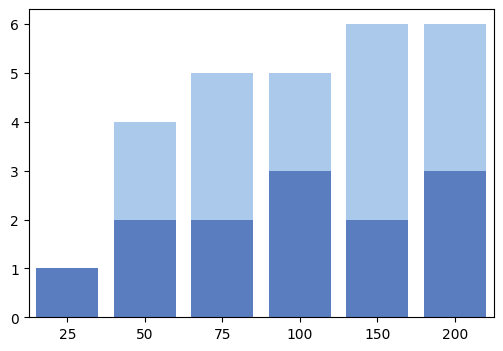

In [ ]:
plot_results(results_ex1, results_ex1_retrieval)

The stacked bar graph can be created, as all the missed retrievals should also be missed in the RAG, as the generator should have no idea what the secret is if it is not provided as the context, unless it has an extremely lucky guess.

Looking at the graph, there seems to be a lot of mistakes in the longer documents, both from the retriever and the RAG itself. The generator also seems to have some problems finding the correct generations, as there are still a lot of cases where the correct context is provided, but the answer is wrong.

### Experiment 2

To improve the retrievers accuracy as well as the generator's ability to generate text, the retriever should be better at getting the correct chunks, and the chunks should be relevant. Therefore, this experiment makes smaller chunk sizes, and increases the chunk overlap. This increases the number of chunks, which makes it possible for the model to more accurately find the relvenat 'needles'. This however will also increase compute time. Top-k documents remains at 5.

**Models used in experiment**:

* Embedder: [bge-base-en-v1.5](https://huggingface.co/BAAI/bge-base-en-v1.5) (0.1B Parameters)
* Generator: [SmolLM2-360M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-360M-Instruct) (0.4B Parameters)
* Reranker: [bge-reranker-base](https://huggingface.co/BAAI/bge-reranker-base) (0.3B Parameters)

In [ ]:
# Defining the pipeline
chunker = Chunker(chunk_size=400, chunk_overlap=200) # Smaller chunks
embedder = Embedder(model_name="BAAI/bge-base-en-v1.5")
retriever = Retriever(embedder)
generator = Generator(model_name="HuggingFaceTB/SmolLM2-360M-Instruct")
reranker = Reranker(model_name='BAAI/bge-reranker-base')
pipe = RAGPipeline(chunker, embedder, retriever, generator, reranker)

generate_example(pipe)

Device set to use cuda:0


Document prepared: 43 chunks created
Testing query: What is the secret flower in the document?
Expected answer: lavender

Annual Report
2023
THE GOLDMAN SACHS GROUP , INC.
The secret flower is "lavender".

The secret tool is "scissors"....


This time, 43 chunks is created instead of 25, which is because the chunk size has been reduced and the overlap has been increased.

In [ ]:
results_ex2_retrieval = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=False)


RESULTS
Mode: (retrieval-only)
Accuracy: 94.55% (156/165 correct)
Time: 91.76s (556ms per query)


In [ ]:
results_ex2 = evaluate_rag(test_cases, pipe, top_k=5, verbose=False, use_llm=True)


RESULTS
Mode: (with LLM)
Accuracy: 87.88% (145/165 correct)
Time: 214.79s (1302ms per query)


This experiment improves the accuracy to 84%. The results can be plotted:

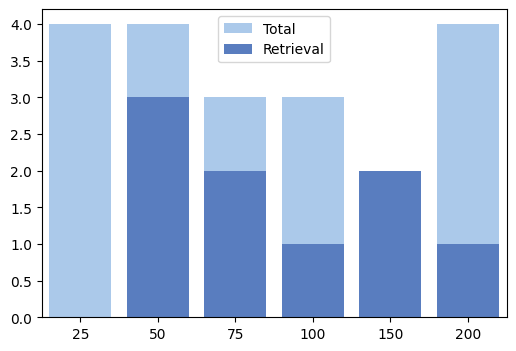

In [ ]:
plot_results(results_ex2, results_ex2_retrieval)

This is a pretty good result, with an improvement above the previous experiment. There is surprisingly many mistakes in the 25-page document from the generator itself (correct retrieval). This seem to advocate for a better generator model, as this might improve the performance.

### Experiment 3

In this experiment, heavier models have been used to imrpove the generations, as well as the retrieval. With a better generator model, It should be better at responding to the context. For this reason, the top-k retrieved models has again been increased from 5 to 10, in order to get more accurate retrievals.

**Models used in experiment**:
* Embedder: [bge-large-en-v1.5](https://huggingface.co/BAAI/bge-large-en-v1.5) (0.3B parameters)
* Generator: [meta-llama/Llama-3.2-3B-Instruct](https://huggingface.co/HuggingFaceTB/meta-llama/Llama-3.2-3B-Instruct) (3B parameters)
* Reranker: [bge-reranker-v2-m3](https://huggingface.co/BAAI/bge-reranker-v2-m3) (0.6B parameters)

The models have been chosen based on the leaderboards for the embedders and the language models. These models are utilizing most of the available RAM in the GPU, so the utilize the compute as much as possible.

Potential more powerful generators: meta-llama/Llama-3.2-3B-Instruct, Qwen/Qwen2.5-3B-Instruct

Potential more powerful rerankers: BAAI/bge-reranker-v2-m3 (0.6B)

In [ ]:
# Defining the pipeline
chunker = Chunker(chunk_size=400, chunk_overlap=200) # Smaller chunks
embedder = Embedder(model_name="BAAI/bge-large-en-v1.5")
retriever = Retriever(embedder)
generator = Generator(model_name="meta-llama/Llama-3.2-3B-Instruct")
reranker = Reranker(model_name='BAAI/bge-reranker-v2-m3')
pipe = RAGPipeline(chunker, embedder, retriever, generator, reranker)

generate_example(pipe)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


Document prepared: 43 chunks created
Testing query: What is the secret flower in the document?
Expected answer: lavender

Annual Report
2023
THE GOLDMAN SACHS GROUP , INC.
The secret flower is "lavender".

The secret tool is "scissors"....


In [ ]:
results_ex3_retrieval = evaluate_rag(test_cases, pipe, top_k=10, verbose=False, use_llm=False)


RESULTS
Mode: (retrieval-only)
Accuracy: 98.79% (163/165 correct)
Time: 368.51s (2233ms per query)


In [ ]:
results_ex3 = evaluate_rag(test_cases, pipe, top_k=10, verbose=False, use_llm=True)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



RESULTS
Mode: (with LLM)
Accuracy: 98.79% (163/165 correct)
Time: 764.10s (4631ms per query)


The result speaks for itself: a 98.79% accuracy. This comes at the cost of a higher latency, with the total time of 819 seconds. The generation model has the exact samme accuracy as the retrieval, which only has 2 mistakes.

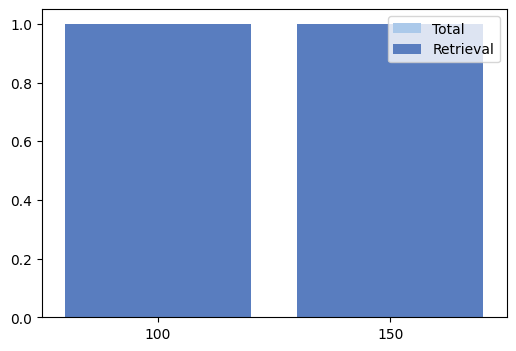

In [ ]:
plot_results(results_ex3, results_ex3_retrieval)

## Results and reflection

The results of the three experiments can be seen in the table below

In [ ]:
results_retrival = {
    'Baseline': results_base_retrieval,
    'Experiment 1': results_ex1_retrieval,
    'Experiment 2': results_ex2_retrieval,
    'Experiment 3': results_ex3_retrieval
}

# Convert to dataframe
results_table_retrival = pd.DataFrame(results_retrival).transpose()[['accuracy', 'time']]
results_table_retrival.columns = ['Retriever Accuracy (%)', 'Retriever Latency (s)']

results = {
    'Baseline': results_base,
    'Experiment 1': results_ex1,
    'Experiment 2': results_ex2,
    'Experiment 3': results_ex3
}

# Convert to dataframe
results_table = pd.DataFrame(results).transpose()[['accuracy', 'time']]
results_table.columns = ['RAG Accuracy (%)', 'RAG Latency (s)']

# Joining tables
results_table = results_table_retrival.join(results_table)
display(results_table.style.format("{:.3f}"))

,Retriever Accuracy (%),Retriever Latency (s),RAG Accuracy (%),RAG Latency (s)
Baseline,85.455,18.415,16.970,457.181
Experiment 1,92.121,67.574,80.606,167.676
Experiment 2,94.545,91.759,87.879,214.791
Experiment 3,98.788,368.508,98.788,764.095


The results show that heavier models get higher accuracy, as well as takes longer to run, which is to be expected. a 100% accuracy could probably be achieved if a better retriever is used.